# Application 1 — Diabetes Prediction

## 1. Problem Definition

### Objective

The objective of this application is to predict whether a patient is diagnosed with diabetes based on demographic, lifestyle, medical-history, and clinical health indicators.

The prediction target is `diagnosed_diabetes`:

- `0` = No diabetes
- `1` = Diabetes

This is a binary classification problem.

This is a binary classification problem.

## Problem Formulation

Let:

$$
X = \text{patient features}
$$

and:

$$
y = \text{diagnosed\_diabetes}
$$

For one patient, the feature representation can be written as:

$$
x_i = [x_{i1}, x_{i2}, \ldots, x_{id}]^T \in \mathbb{R}^d
$$

For the complete dataset:

$$
X \in \mathbb{R}^{N \times d}
$$

where:

- $N$ = number of patient observations
- $d$ = number of input features after feature preparation
- $x_i$ = feature vector representing one patient

The goal is to learn a function:

$$
f: X \rightarrow y
$$

that can predict the diabetes class of a new patient.

## Why this problem is useful

A classification model can identify patterns associated with diabetes-related risk factors and provide a prediction that can later be exposed through a web service and mobile application.

The model is intended as an educational machine-learning system and should not be interpreted as a clinical diagnosis.


# 2. Dataset Source

## Kaggle Dataset

**Dataset name:** Diabetes Health Indicators Dataset

**Kaggle URL:**

https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset

The selected dataset contains approximately 100,000 patient records and includes demographic, lifestyle, medical-history, and clinical health indicators.

Representative features include variables related to:

- age;
- gender;
- ethnicity;
- education;
- income;
- employment;
- smoking;
- physical activity;
- BMI;
- blood pressure;
- cholesterol;
- glucose;
- insulin;
- HbA1c;
- and other health indicators.

The target variable selected for this application is:

`diagnosed_diabetes`

The original dataset may also contain identifier variables and variables derived from diabetes status. Such variables must be investigated before model training to reduce the risk of target leakage.

# 3. Dataset loading

The analysis uses a fixed random seed so that stochastic operations such as data splitting and model training can be reproduced.

The computational environment is also recorded because reproducibility depends not only on the dataset and code, but also on the software environment in which the experiment is executed.

In [29]:
# ============================================================
#  Import libraries and configure reproducibility
# ============================================================

import os
import sys
import platform
import random
import time
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Fixed seed for reproducible splitting and model training
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Python version :", sys.version)
print("Operating system:", platform.platform())
print("Pandas version :", pd.__version__)
print("NumPy version  :", np.__version__)
print("Random seed    :", RANDOM_SEED)

Python version : 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Operating system: Windows-11-10.0.26200-SP0
Pandas version : 3.0.3
NumPy version  : 2.4.6
Random seed    : 42


In [30]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

DATA_PATH = "../../DATA/diabetes_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Cannot find '{DATA_PATH}'. "
        "Please place the Kaggle CSV file in the notebook directory."
    )

df_raw = pd.read_csv(DATA_PATH)

# Keep untouched raw data
df = df_raw.copy()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Pandas version: 3.0.3
NumPy version: 2.4.6
Dataset loaded successfully.
Shape: (100000, 31)


# 4. Dataset Inspection
### What does one observation represent?

For this application, one row represents the health profile of **one patient/individual**.

### What does one column represent?

Each column represents one attribute of the patient, such as:

- demographic information;
- lifestyle information;
- medical history;
- clinical measurements;
- or the target variable.

### What is the target?

The target is:

`diagnosed_diabetes`

It is separated from the input features before model training.

In [31]:
# ============================================================
#  Dataset Inspection
# ============================================================

print("1. DATASET SHAPE")
print(df.shape)

print("\n2. FIRST FIVE ROWS")
display(df.head())

print("\n3. DATAFRAME INFORMATION")
df.info()

print("\n4. DESCRIPTIVE STATISTICS")
display(df.describe(include="all").T)

1. DATASET SHAPE
(100000, 31)

2. FIRST FIVE ROWS


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1



3. DATAFRAME INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,50.12041,15.6046,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,118.91164,84.409662,0.0,57.0,100.0,160.0,833.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0


# 5. Data-Quality And Missing Values Analysis

The objective of data-quality analysis is to identify problems that may affect machine-learning performance.

The analysis investigates:

- missing values;
- duplicated observations;
- invalid values;
- statistical outliers;
- incorrect data types;
- categorical inconsistencies;
- class imbalance;
- identifier columns;
- potential target leakage.

The important principle is:

> Data-quality operations should be justified rather than performed automatically.

In [32]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2),
    "unique_values": df.nunique(dropna=False)
})

display(
    quality_summary.sort_values(
        "missing_count",
        ascending=False
    )
)

,dtype,missing_count,missing_percentage,unique_values
age,int64,0,0.0,73
gender,str,0,0.0,3
ethnicity,str,0,0.0,5
education_level,str,0,0.0,4
income_level,str,0,0.0,5
employment_status,str,0,0.0,4
smoking_status,str,0,0.0,3
alcohol_consumption_per_week,int64,0,0.0,11
physical_activity_minutes_per_week,int64,0,0.0,620
diet_score,float64,0,0.0,101


In [33]:
# Potential identifier columns

potential_id_columns = [
    col for col in df.columns
    if (
        col.lower() == "id"
        or col.lower().endswith("_id")
        or "patient_id" in col.lower()
    )
]

print("Potential identifier columns:")
print(potential_id_columns)

Potential identifier columns:
[]


# 6. Duplicate Analysis

## Question

> Are there exact duplicate rows, and should they be removed?

Exact duplicate records can cause repeated observations to receive excessive influence during training.

However, duplicates should not be removed blindly.

We first measure them, then determine whether removal is justified.

In [34]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

if duplicate_count > 0:
    duplicate_percentage = (
        duplicate_count / len(df) * 100
    )
    print(
        f"Percentage of duplicated rows: "
        f"{duplicate_percentage:.2f}%"
    )

    display(
        df[df.duplicated(keep=False)]
        .head(20)
    )

Number of duplicated rows: 0


# 7. Invalid-Value Analysis

## Question

> Are any numerical values outside a plausible domain range?

A value can be numerically valid but semantically invalid.

Examples:

- negative physical measurements;
- impossible ages;
- impossible blood-pressure values;
- invalid BMI;
- invalid glucose measurements.

The goal is not to remove unusual values automatically.

First, potentially invalid observations are identified.

In [35]:
# Candidate domain ranges.
# The cells below only check columns that actually exist.

expected_ranges = {
    "age": (18, 90),
    "bmi": (15, 45),
    "systolic_bp": (90, 180),
    "diastolic_bp": (60, 120),
    "heart_rate": (50, 120),
    "glucose_fasting": (70, 250),
    "glucose_postprandial": (90, 350),
    "insulin_level": (2, 50),
    "hba1c": (4, 14),
    "cholesterol_total": (120, 300),
    "hdl_cholesterol": (20, 100),
    "ldl_cholesterol": (50, 200),
    "triglycerides": (50, 500),
}

invalid_records = []

for col, (lower, upper) in expected_ranges.items():

    if col not in df.columns:
        continue

    invalid_mask = (
        (df[col] < lower)
        | (df[col] > upper)
    )

    invalid_count = int(invalid_mask.sum())

    invalid_records.append({
        "feature": col,
        "allowed_min": lower,
        "allowed_max": upper,
        "invalid_count": invalid_count,
        "invalid_percentage": round(
            invalid_count / len(df) * 100,
            4
        )
    })

invalid_df = pd.DataFrame(invalid_records)

if invalid_df.empty:
    print("No predefined-range checks matched the dataset columns.")
else:
    display(invalid_df)

,feature,allowed_min,allowed_max,invalid_count,invalid_percentage
0,age,18,90,0,0.000
1,bmi,15,45,0,0.000
2,systolic_bp,90,180,0,0.000
3,diastolic_bp,60,120,2760,2.760
4,heart_rate,50,120,808,0.808
5,glucose_fasting,70,250,97,0.097
6,glucose_postprandial,90,350,1129,1.129
7,insulin_level,2,50,0,0.000
8,hba1c,4,14,0,0.000
9,cholesterol_total,120,300,1999,1.999


# 8. Outlier Analysis

## Question

> Which numerical variables contain statistically extreme observations, and are these observations errors or valid extremes?

### Method: Interquartile Range (IQR)

We use the **Interquartile Range (IQR)** to identify statistically extreme observations.

$$
IQR = Q_3 - Q_1
$$

where:

- $Q_1$ is the **first quartile (25th percentile)**
- $Q_3$ is the **third quartile (75th percentile)**

### Outlier Rule

An observation $x$ is considered a statistical outlier if it satisfies either of the following conditions:

**Lower outlier:**

$$
x < Q_1 - 1.5 \times IQR
$$

**Upper outlier:**

$$
x > Q_3 + 1.5 \times IQR
$$

### Interpretation

The IQR method identifies **statistically extreme observations** based on their distance from the central distribution.

However, being an outlier **does not automatically mean that the observation is incorrect**.

In medical datasets, unusual values may represent:

- genuine patient conditions,
- rare but valid cases,
- measurement variation,
- or data-entry errors.

Therefore, outliers should be **investigated in context** before deciding whether they should be removed, transformed, or retained.

> **Important:** Statistical outlier detection identifies unusual observations; it does not prove that those observations are invalid.

In [36]:
# ============================================================
# IQR-based outlier detection
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# The target is excluded from feature outlier analysis
outlier_features = [
    col for col in numeric_columns
    if col != "diagnosed_diabetes"
]

outlier_results = []

for col in outlier_features:

    series = df[col].dropna()

    if series.empty:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    count = int(mask.sum())

    outlier_results.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
        "outlier_percentage": round(
            count / len(df) * 100,
            2
        )
    })

outlier_df = pd.DataFrame(
    outlier_results
).sort_values(
    "outlier_percentage",
    ascending=False
)

display(outlier_df)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
6,family_history_diabetes,0.00,0.00,0.00,0.000,0.000,21941,21.94
8,cardiovascular_history,0.00,0.00,0.00,0.000,0.000,7920,7.92
2,physical_activity_minutes_per_week,57.00,160.00,103.00,-97.500,314.500,3199,3.20
22,diabetes_risk_score,23.80,35.60,11.80,6.100,53.300,914,0.91
4,sleep_hours_per_day,6.30,7.70,1.40,4.200,9.800,900,0.90
13,heart_rate,64.00,75.00,11.00,47.500,91.500,855,0.85
9,bmi,23.20,28.00,4.80,16.000,35.200,744,0.74
18,glucose_fasting,102.00,120.00,18.00,75.000,147.000,745,0.74
12,diastolic_bp,70.00,81.00,11.00,53.500,97.500,731,0.73
19,glucose_postprandial,139.00,181.00,42.00,76.000,244.000,634,0.63


# 9. Exploratory Data Analysis

## Objective

EDA is used to understand the structure of the patient population and investigate relationships between patient characteristics and diabetes diagnosis.

The analysis examines:

- target distribution;
- numerical feature distributions;
- feature–target relationships;
- categorical distributions;
- categorical–target relationships;
- pairwise relationships between important numerical variables;
- correlation structure.


In [38]:
# ============================================================
# Target distribution summary
# ============================================================

TARGET = "diagnosed_diabetes"

target_counts = (
    df[TARGET]
    .value_counts()
    .sort_index()
)

target_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

,count,percentage
diagnosed_diabetes,,
0,40002,40.0
1,59998,60.0


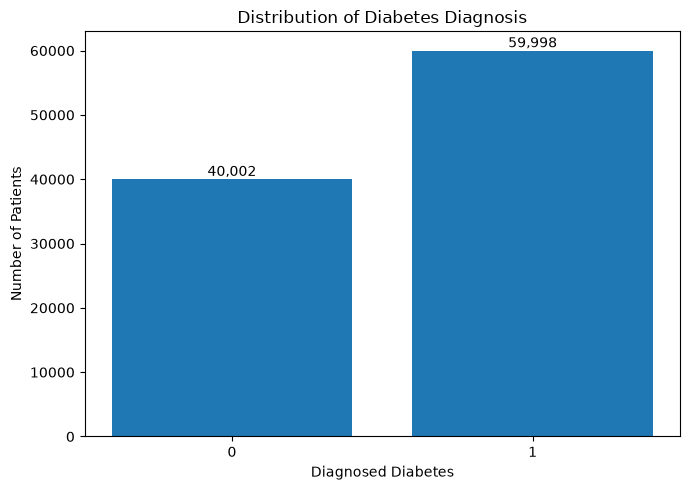

In [39]:
# ============================================================
# Target distribution bar chart
# ============================================================

plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.title(
    "Distribution of Diabetes Diagnosis"
)
plt.xlabel("Diagnosed Diabetes")
plt.ylabel("Number of Patients")

for bar, value in zip(
    bars,
    target_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Numerical-distribution interpretation

**Observation:**  
The histograms reveal the central tendency, spread, skewness, and possible extreme values of the main numerical variables.

**Interpretation:**  
Some health measurements may be approximately symmetric, while others may be skewed or concentrated within particular ranges.

**ML implication:**  
Different distributions may influence the behavior of algorithms. Standardization is particularly useful for distance-based and linear models, while tree-based models are generally less dependent on feature scale.

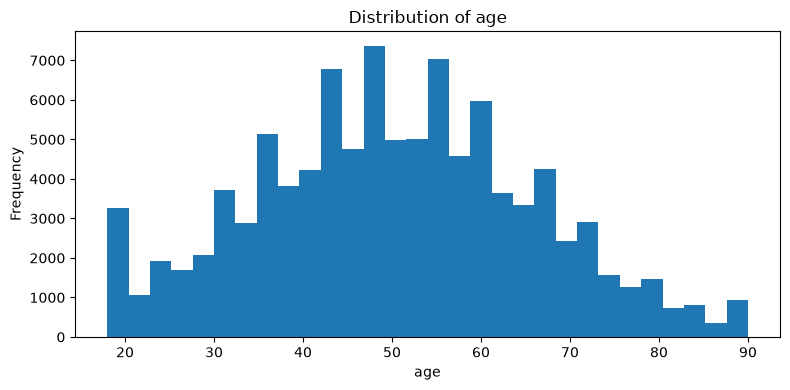

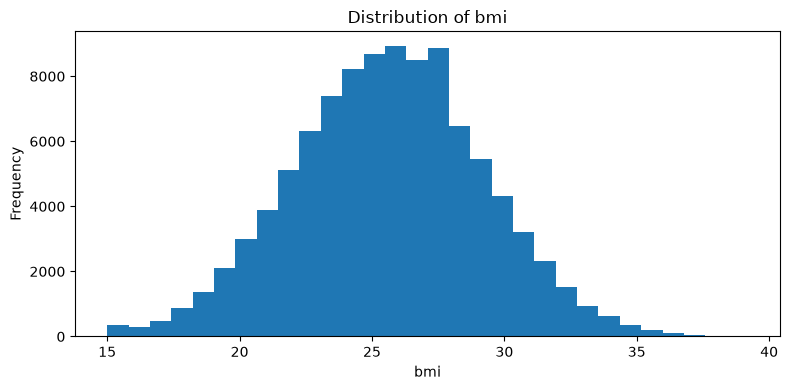

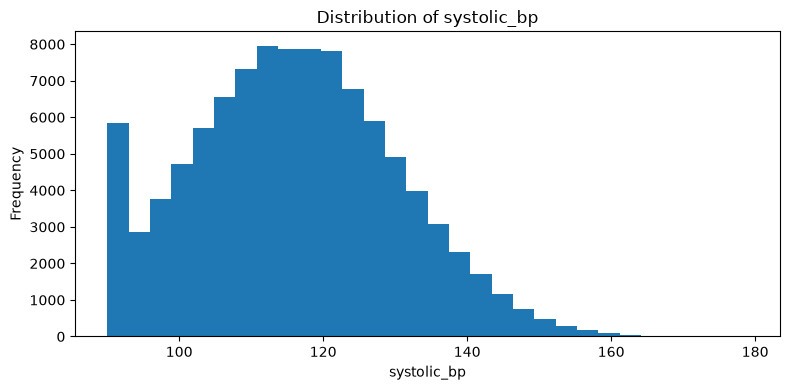

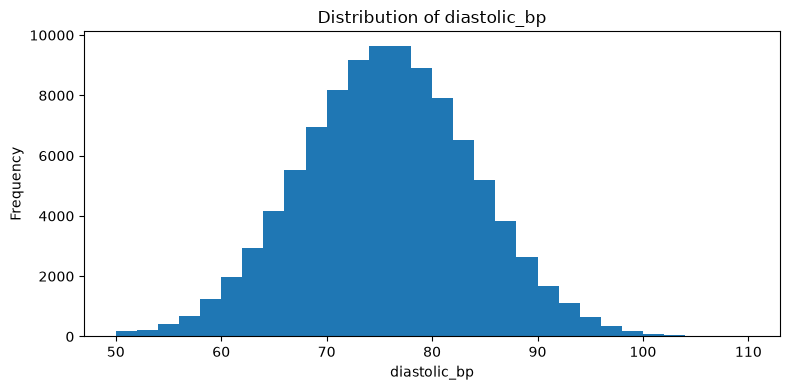

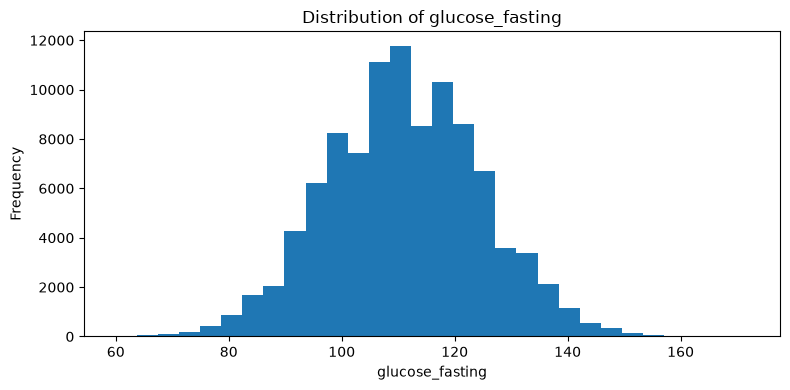

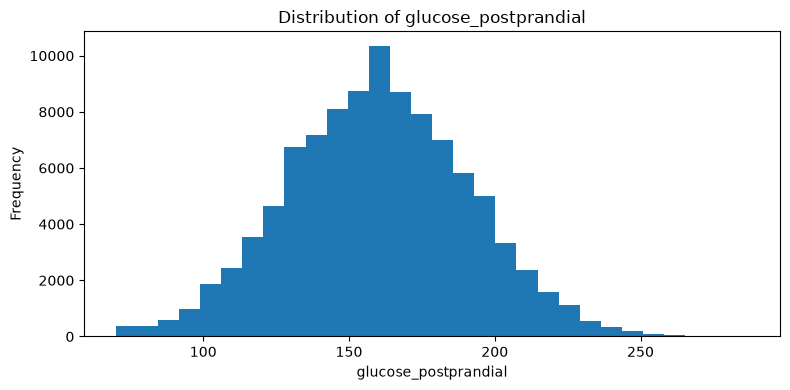

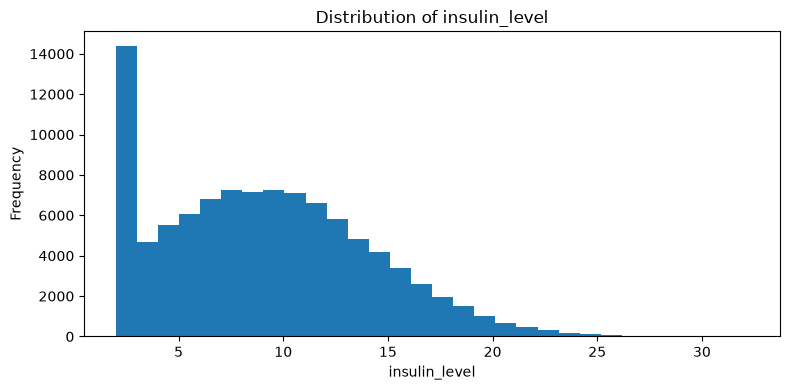

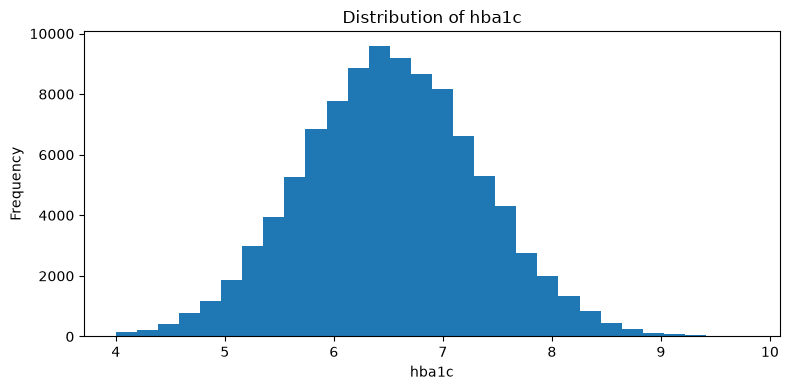

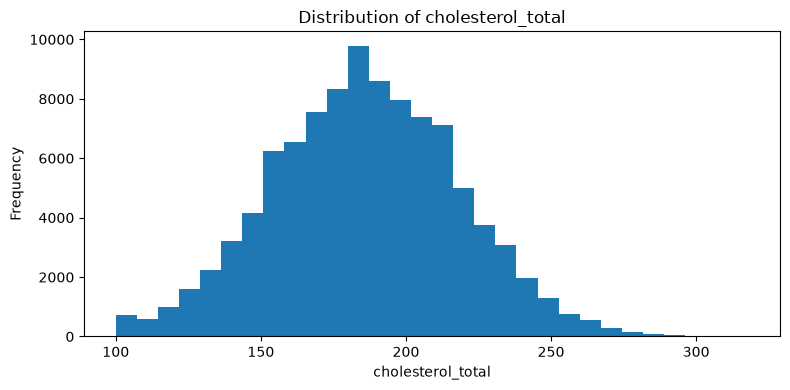

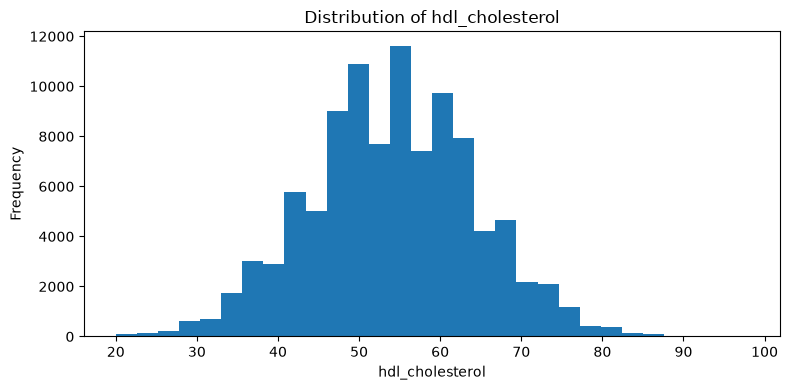

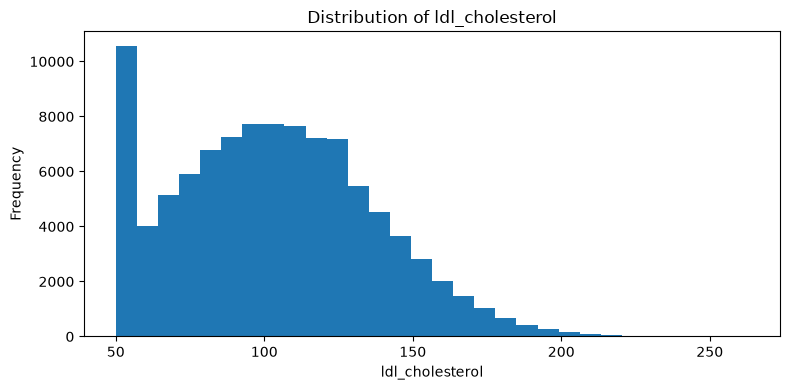

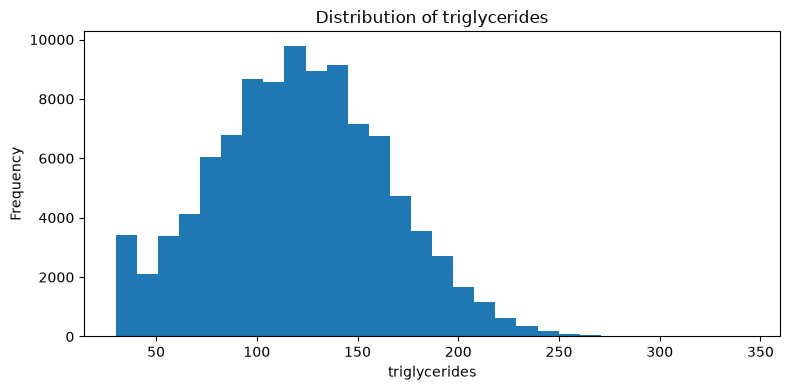

In [40]:
# ============================================================
# Histograms for important numerical variables
# ============================================================

important_numeric = [
    "age",
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides"
]

available_numeric = [
    col
    for col in important_numeric
    if col in df.columns
]

for feature in available_numeric:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df[feature].dropna(),
        bins=30
    )

    plt.title(
        f"Distribution of {feature}"
    )
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Feature–target interpretation

**Observation:**  
The boxplots compare the distributions of individual numerical variables between diabetes classes.

**Interpretation:**  
Features with visibly different distributions between classes may contain discriminative information.

**ML implication:**  
Such variables may contribute to classification performance. Nevertheless, visual separation alone is not sufficient evidence of predictive usefulness; final conclusions should be based on validation and test performance.

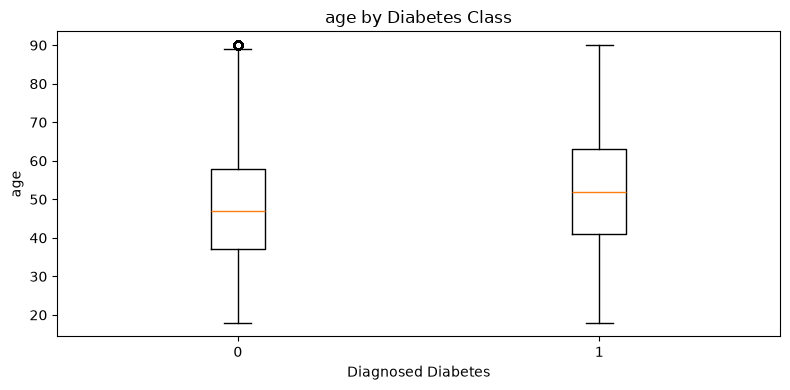

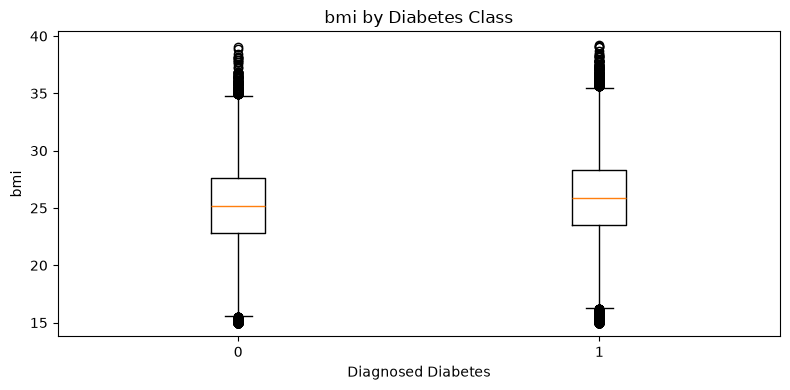

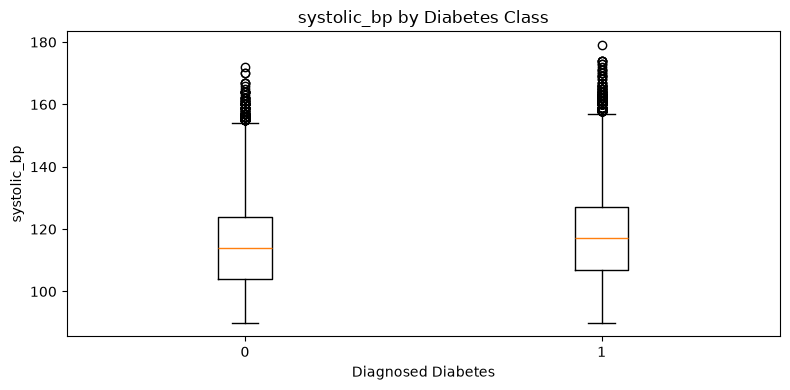

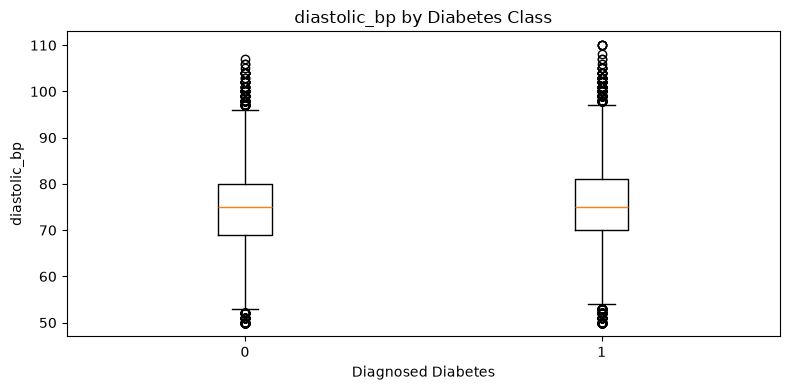

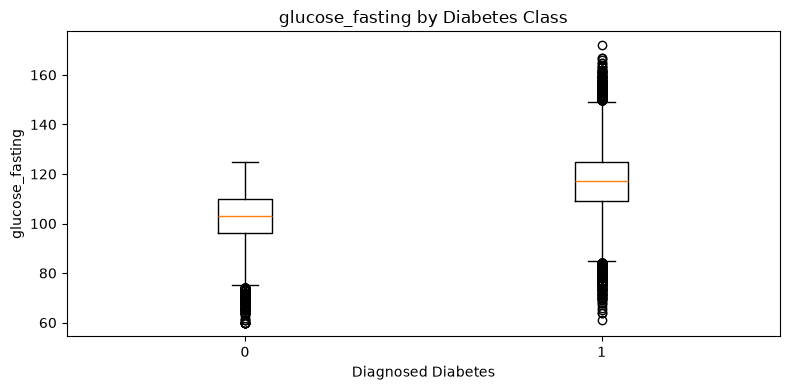

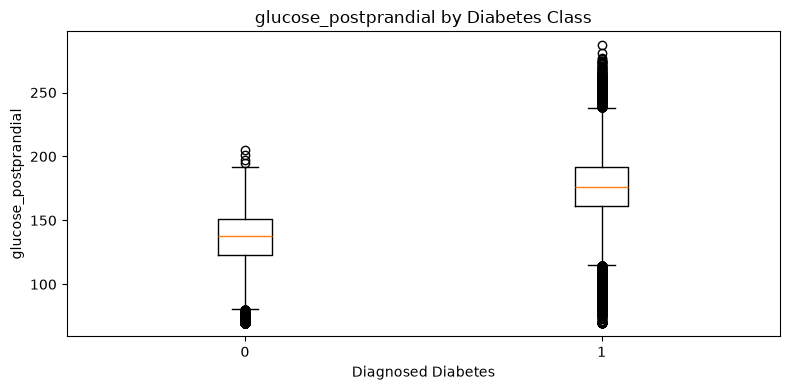

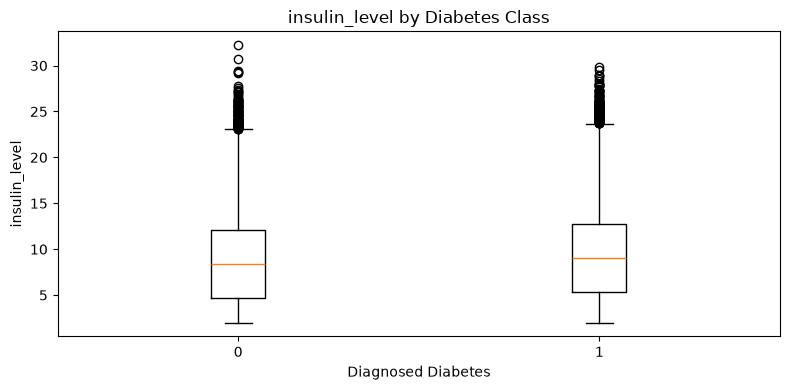

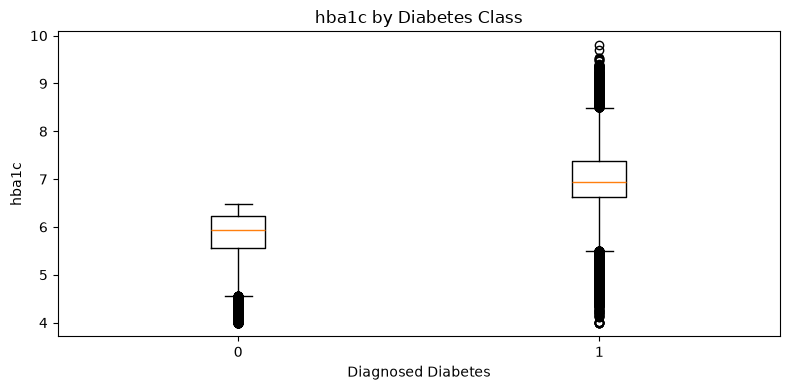

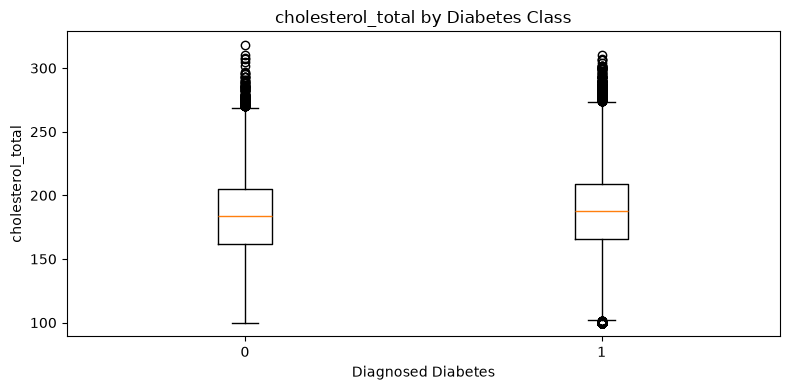

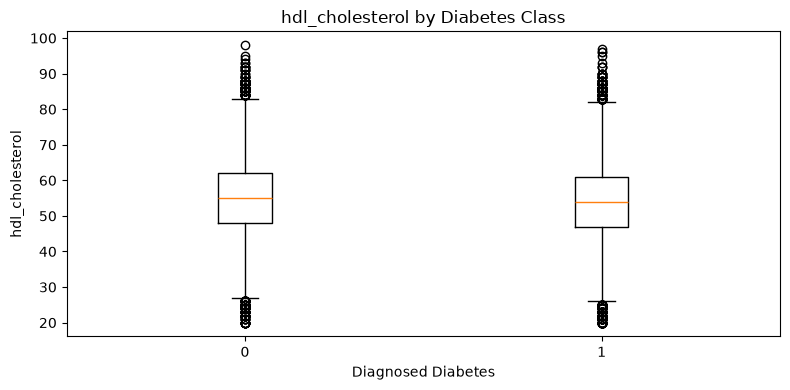

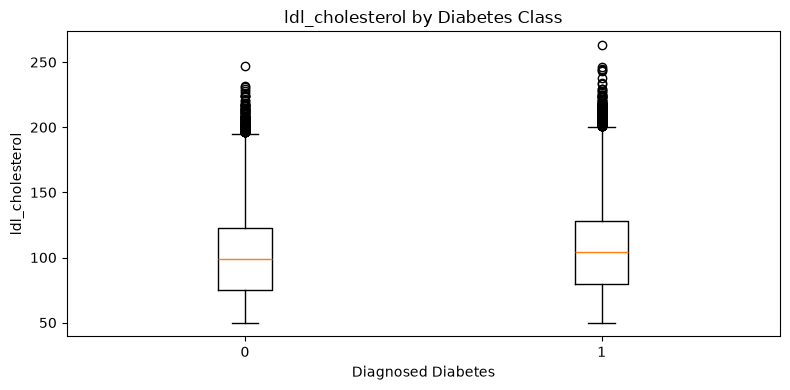

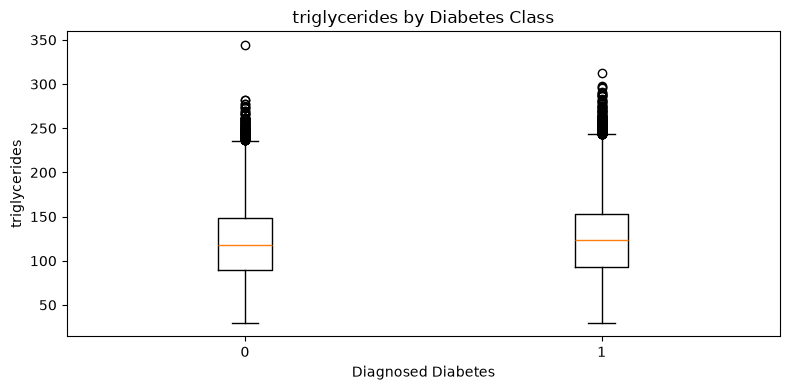

In [41]:
# ============================================================
# Compare numerical variables across target classes
# ============================================================

# Lấy các class thực tế của target
target_classes = sorted(
    df[TARGET].dropna().unique()
)

for feature in available_numeric:

    # Tạo một list dữ liệu cho từng class
    groups = [
        df.loc[
            df[TARGET] == class_value,
            feature
        ].dropna()
        for class_value in target_classes
    ]

    # Vẽ boxplot
    plt.figure(figsize=(8, 4))

    plt.boxplot(
        groups,
        tick_labels=[
            str(class_value)
            for class_value in target_classes
        ]
    )

    plt.title(
        f"{feature} by Diabetes Class"
    )

    plt.xlabel(
        "Diagnosed Diabetes"
    )

    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

### Violin-plot interpretation

Violin plots provide additional information about distribution shape that may not be visible from boxplots alone.

They help reveal:

- concentration of observations;
- multimodal distributions;
- differences in distribution width;
- differences in the density of observations across the feature range.

These patterns can help determine whether the classes are separated by simple shifts in central tendency or by more complex distributional differences.

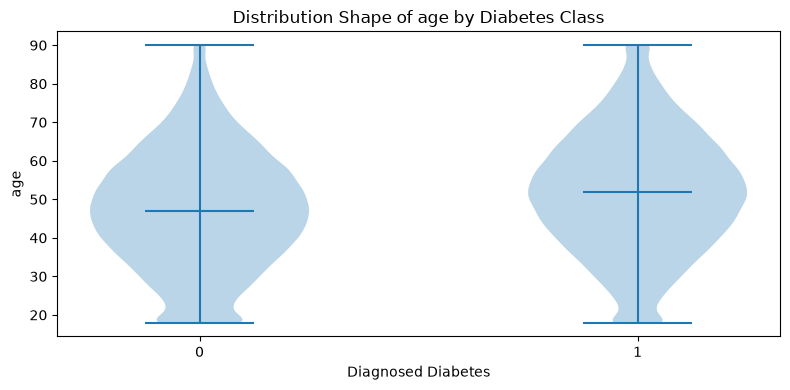

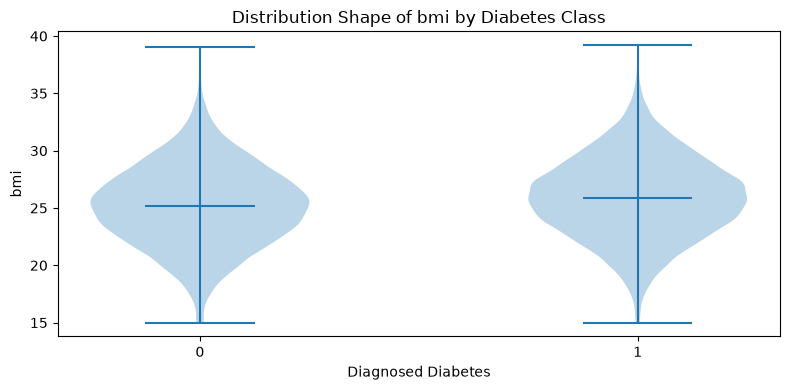

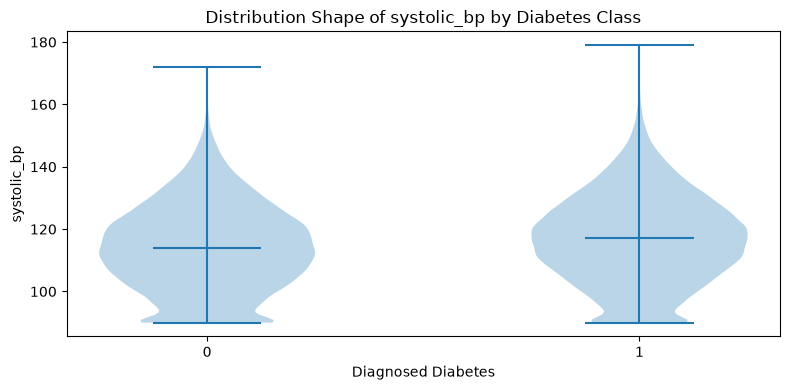

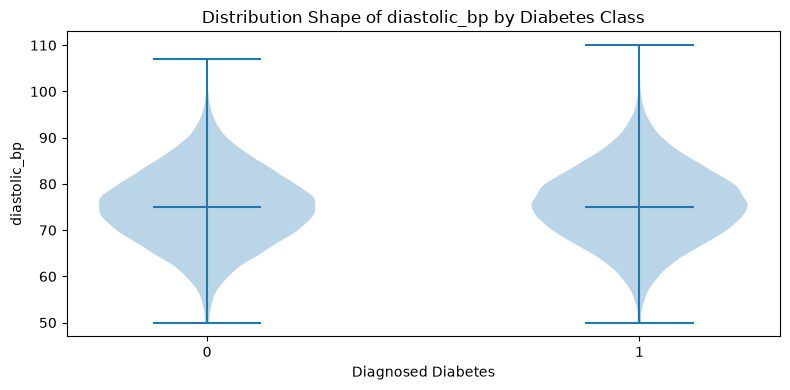

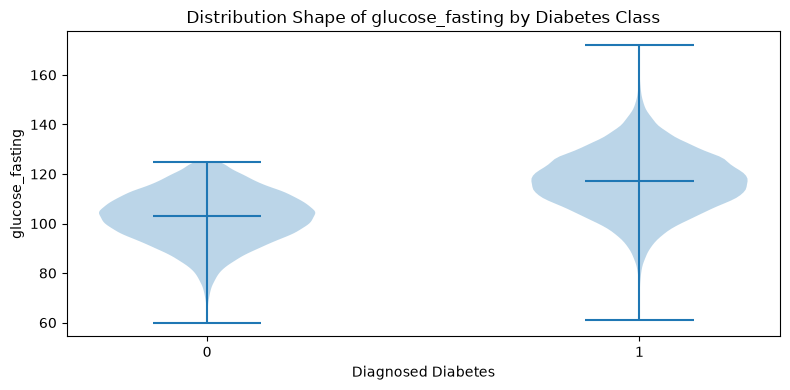

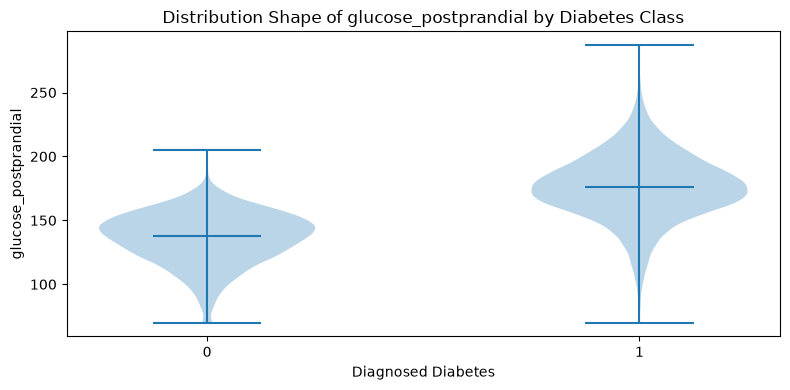

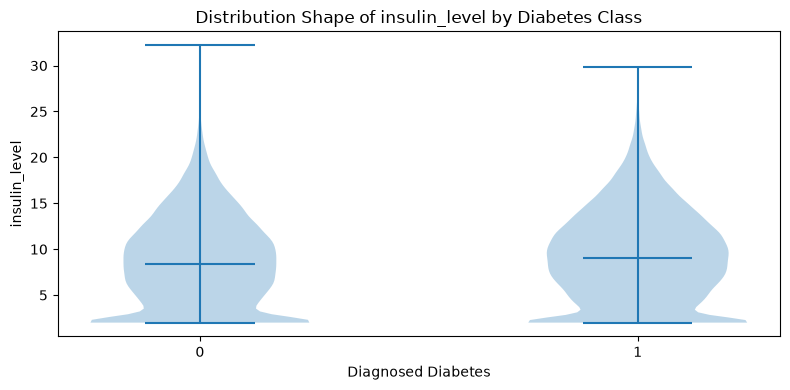

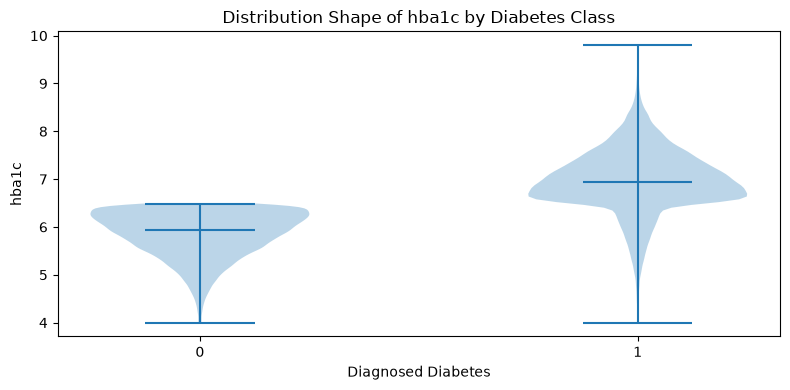

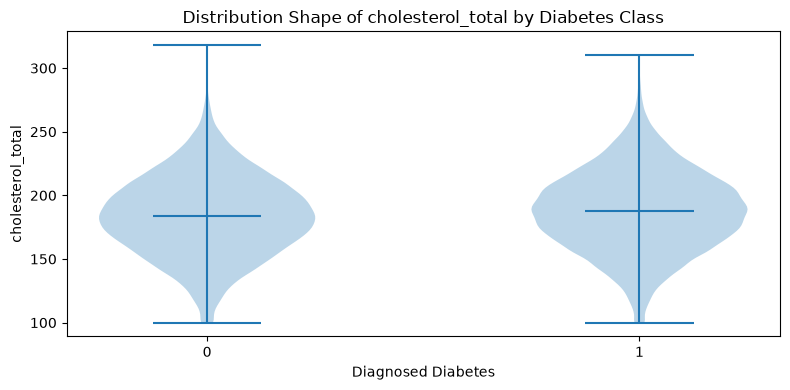

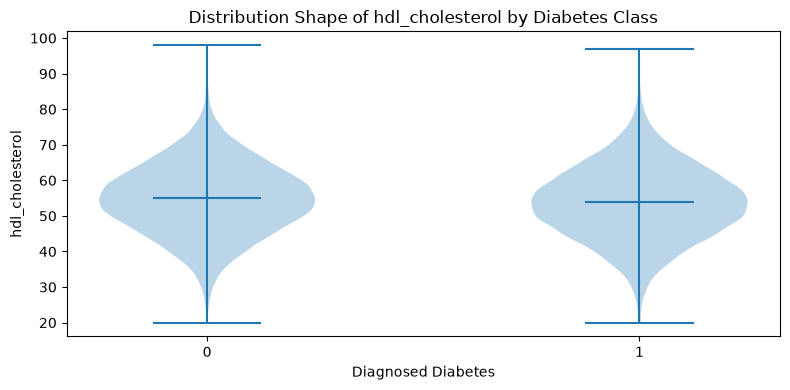

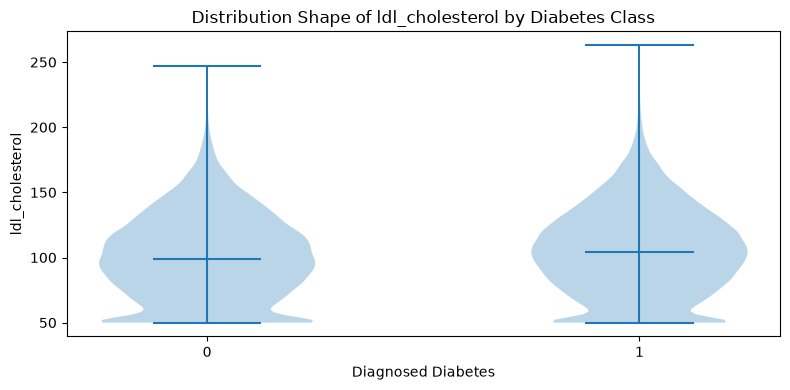

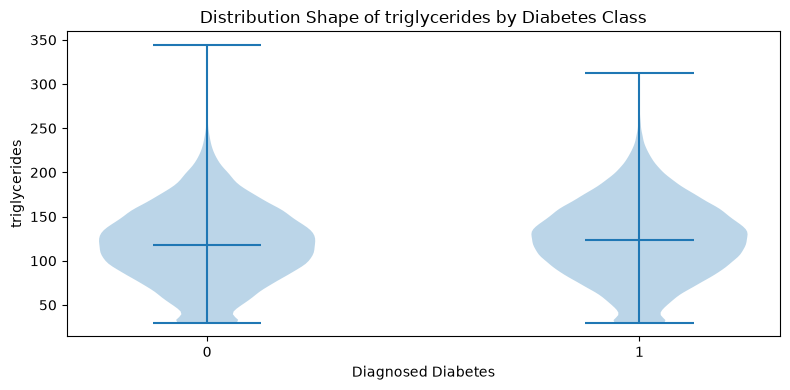

In [42]:
# ============================================================
# Violin plots for distribution shape comparison
# ============================================================

for feature in available_numeric:

    groups = [
        df.loc[
            df[TARGET] == class_value,
            feature
        ].dropna()
        for class_value
        in sorted(df[TARGET].dropna().unique())
    ]

    plt.figure(figsize=(8, 4))

    plt.violinplot(
        groups,
        showmedians=True
    )

    plt.xticks(
        range(1, len(groups) + 1),
        [
            str(class_value)
            for class_value
            in sorted(df[TARGET].dropna().unique())
        ]
    )

    plt.title(
        f"Distribution Shape of {feature} by Diabetes Class"
    )
    plt.xlabel("Diagnosed Diabetes")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [43]:
# ============================================================
# Identify categorical variables
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Remove the target if it happens to be represented categorically
categorical_columns = [
    col
    for col in categorical_columns
    if col != TARGET
]

print("Categorical features:")
for col in categorical_columns:
    print("-", col)

Categorical features:
- gender
- ethnicity
- education_level
- income_level
- employment_status
- smoking_status
- diabetes_stage


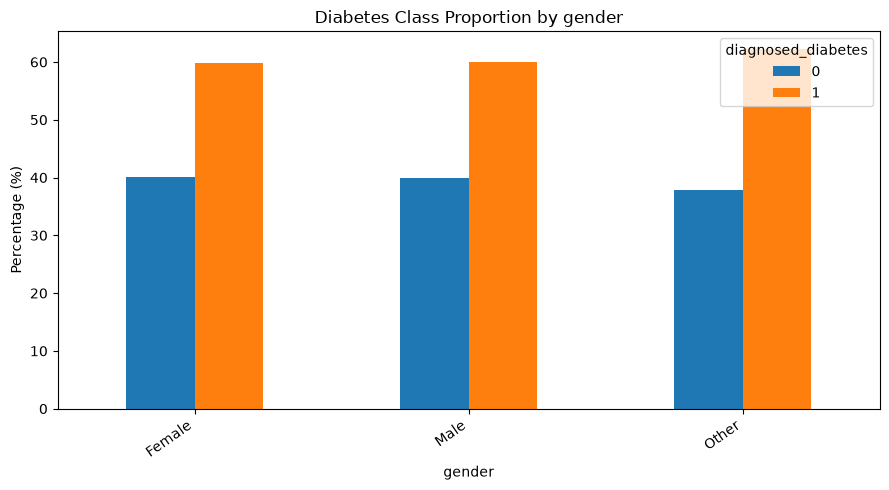

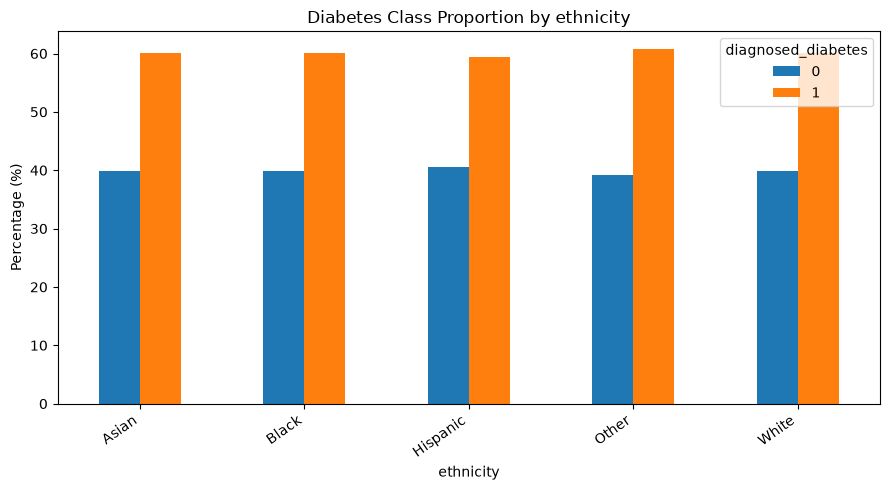

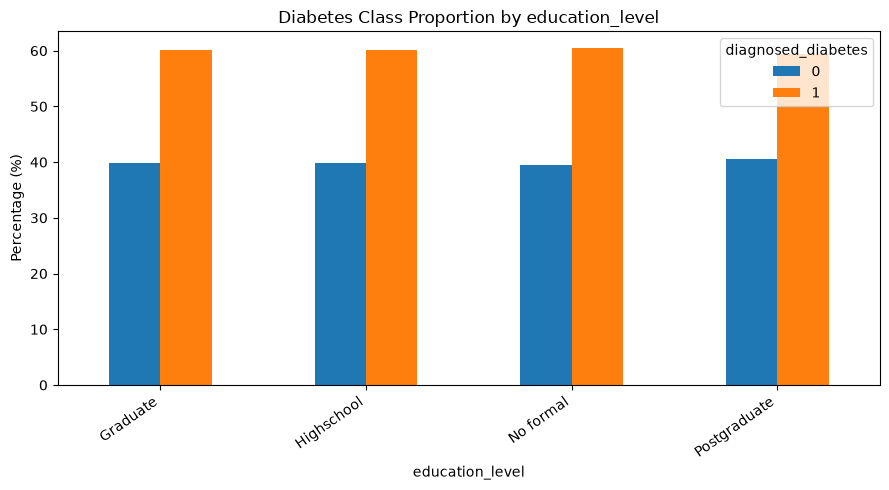

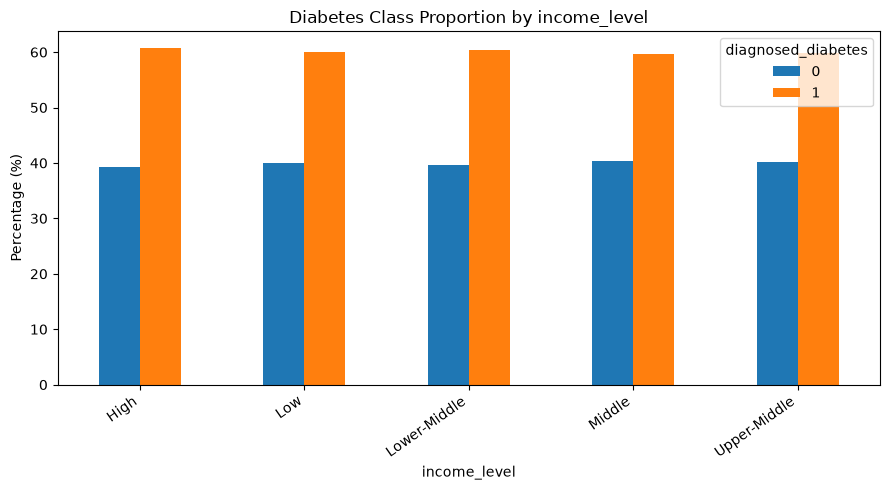

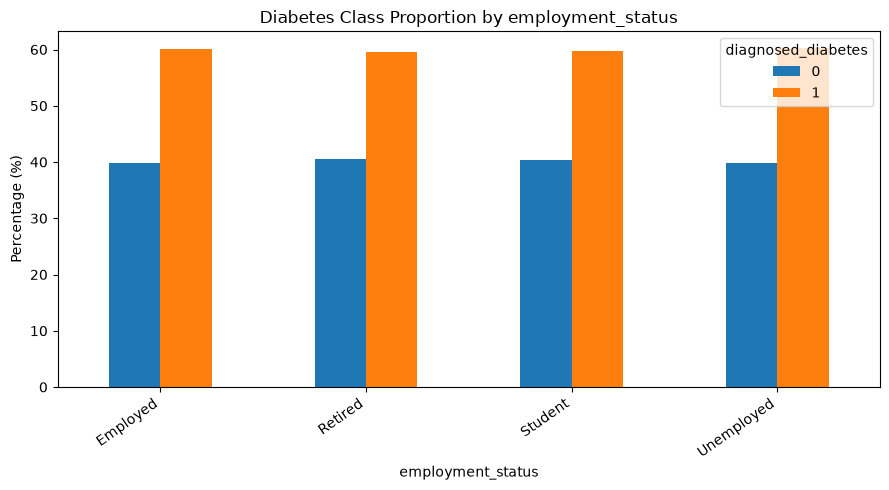

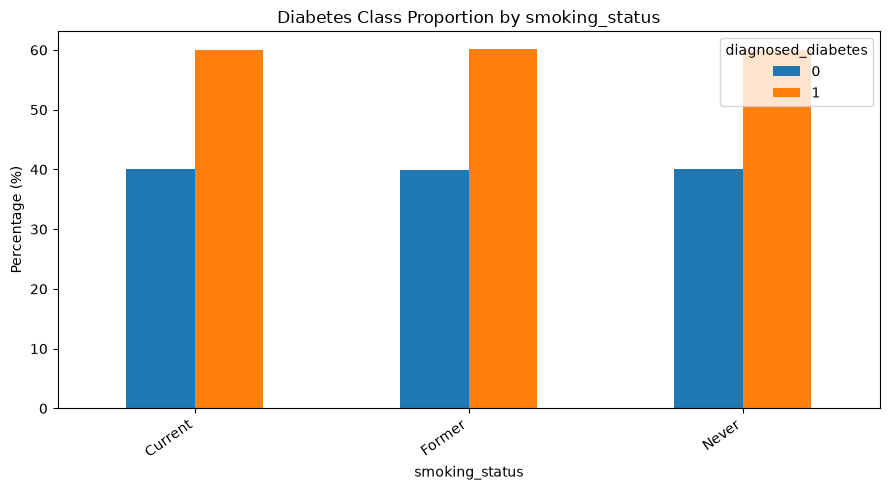

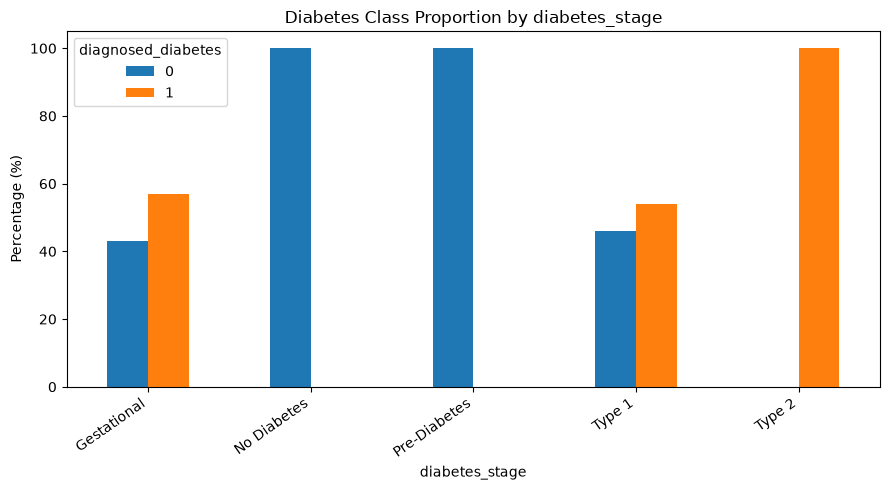

In [44]:
# ============================================================
# Diabetes proportion within categories
# ============================================================

for feature in categorical_columns:

    proportion_table = (
        pd.crosstab(
            df[feature],
            df[TARGET],
            normalize="index"
        )
        .mul(100)
    )

    proportion_table.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(
        f"Diabetes Class Proportion by {feature}"
    )
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")

    plt.xticks(
        rotation=35,
        ha="right"
    )

    plt.legend(
        title=TARGET
    )

    plt.tight_layout()
    plt.show()

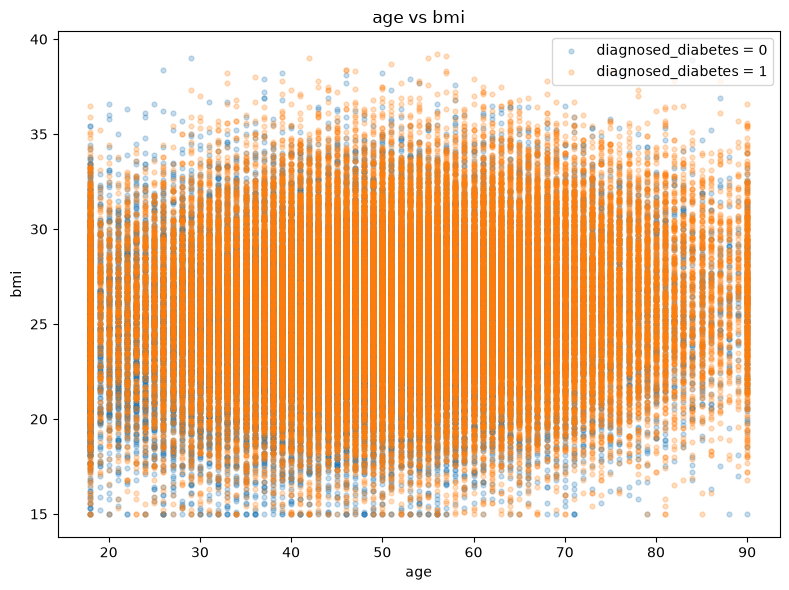

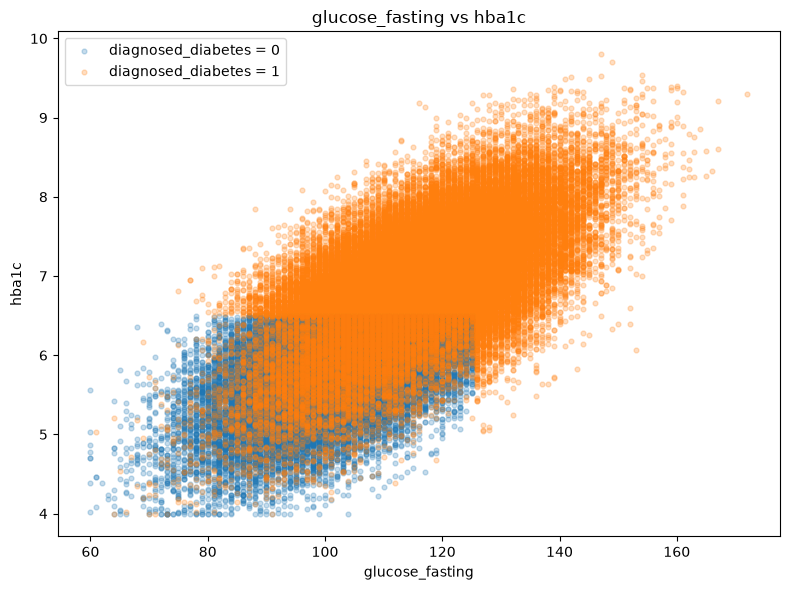

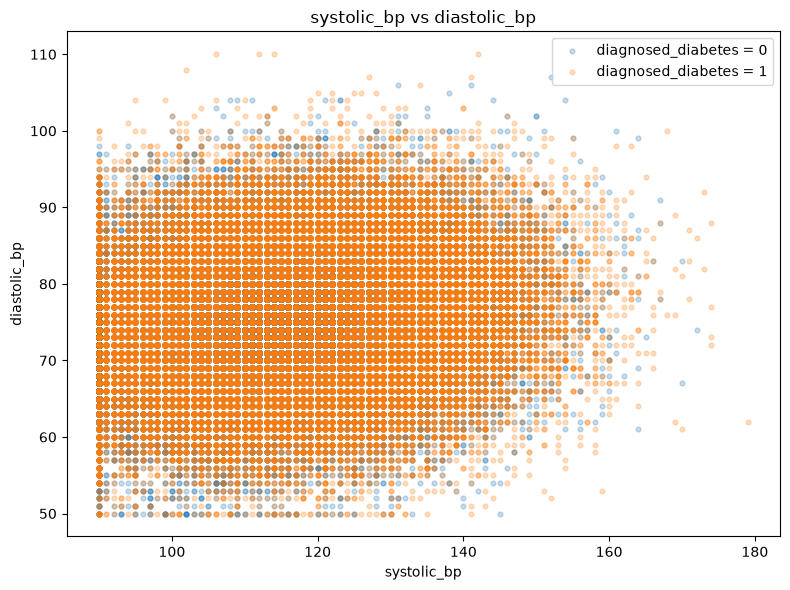

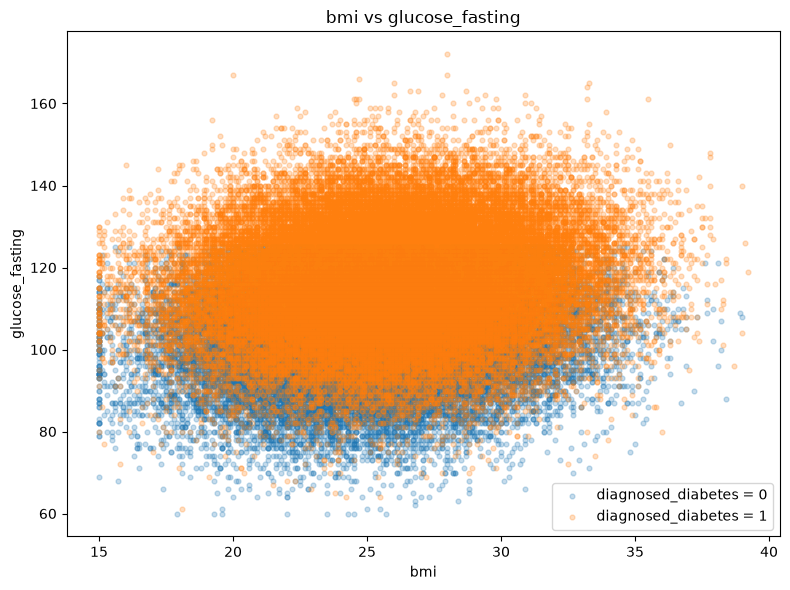

In [46]:
# ============================================================
# Scatter plots for selected feature pairs
# ============================================================

scatter_pairs = [
    ("age", "bmi"),
    ("glucose_fasting", "hba1c"),
    ("systolic_bp", "diastolic_bp"),
    ("bmi", "glucose_fasting")
]

for x_feature, y_feature in scatter_pairs:

    if (
        x_feature not in df.columns
        or y_feature not in df.columns
    ):
        continue

    plt.figure(figsize=(8, 6))

    for class_value in sorted(
        df[TARGET].dropna().unique()
    ):

        subset = df[
            df[TARGET] == class_value
        ]

        plt.scatter(
            subset[x_feature],
            subset[y_feature],
            alpha=0.25,
            s=12,
            label=f"{TARGET} = {class_value}"
        )

    plt.title(
        f"{x_feature} vs {y_feature}"
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend()

    plt.tight_layout()
    plt.show()

# 10. Feature Types

The modeling variables are classified into three conceptual groups:

### Numerical features

These represent measurable quantities such as:

- age;
- BMI;
- blood pressure;
- glucose;
- cholesterol;
- insulin;
- physical activity;
- sleep;
- and related measurements.

### Categorical features

These represent membership in categories, such as:

- gender;
- ethnicity;
- education level;
- income level;
- employment status;
- smoking status.

### Identifier / non-predictive variables

Variables such as patient identifiers identify records rather than represent generalizable patient characteristics.

### Target

The response variable is:

`diagnosed_diabetes`

The target is not part of the input feature matrix.

In [47]:
# ============================================================
# Final feature-type classification
# ============================================================

print("Numerical variables:")
print(
    df.drop(columns=[TARGET], errors="ignore")
      .select_dtypes(include=np.number)
      .columns.tolist()
)

print("\nCategorical variables:")
print(
    df.drop(columns=[TARGET], errors="ignore")
      .select_dtypes(
          include=["object", "category", "bool"]
      )
      .columns.tolist()
)

print("\nPotential identifier variables:")
print(
    [
        col for col in df.columns
        if (
            col.lower() == "id"
            or col.lower().endswith("_id")
            or "patient_id" in col.lower()
        )
    ]
)

Numerical variables:
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score']

Categorical variables:
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']

Potential identifier variables:
[]


# 11. Data Representation

The data representation evolves through several stages:

$$
\text{CSV}
\rightarrow
\text{DataFrame}
\rightarrow
\text{Clean Features}
\rightarrow
\text{Numerical Representation}
\rightarrow
\text{Model Input}
$$

Each stage transforms the data into a representation that is more suitable for analysis and machine learning.

### Patient-Level Representation

For one patient, the feature vector is represented as:

$$
x_i =
[x_{i1}, x_{i2}, \ldots, x_{id}]^T
\in \mathbb{R}^{d}
$$

where:

- $x_i$ = feature vector of patient $i$
- $d$ = number of features in the corresponding representation stage

### Dataset-Level Representation

For $N$ patients, the complete feature matrix is:

$$
X \in \mathbb{R}^{N \times d}
$$

where:

- $N$ = number of patient observations
- $d$ = number of features in the corresponding representation stage

### Effect of Feature Transformation

The number of features may change during preprocessing.

For example, **categorical variables** are converted into numerical features using **One-Hot Encoding**. As a result, one original categorical column can become multiple numerical columns.

Therefore:

$$
d_{\text{final}} \neq d_{\text{original}}
$$

where:

- $d_{\text{original}}$ = number of features before feature transformation
- $d_{\text{final}}$ = number of numerical features provided to the model after preprocessing

> **Important:** The dimension of the final model input is determined by the **processed feature representation**, not simply by the number of original dataset columns.

This distinction is important when describing the model input and interpreting the data representation pipeline.

In [48]:
# ============================================================
# Separate candidate X and target y
# ============================================================

TARGET = "diagnosed_diabetes"

# Candidate columns that should not be used as predictive inputs
IDENTIFIER_COLUMNS = [
    col for col in df.columns
    if (
        col.lower() == "id"
        or col.lower().endswith("_id")
        or "patient_id" in col.lower()
    )
]

# Target-derived variables that require leakage review
TARGET_DERIVED_COLUMNS = [
    col for col in [
        "diabetes_stage",
        "diabetes_risk_score"
    ]
    if col in df.columns
]

EXCLUDED_COLUMNS = list(
    dict.fromkeys(
        [TARGET]
        + IDENTIFIER_COLUMNS
        + TARGET_DERIVED_COLUMNS
    )
)

X = df.drop(
    columns=EXCLUDED_COLUMNS,
    errors="ignore"
)

y = df[TARGET].copy()

print("Excluded columns:")
for col in EXCLUDED_COLUMNS:
    print("-", col)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Excluded columns:
- diagnosed_diabetes
- diabetes_stage
- diabetes_risk_score

X shape: (100000, 28)
y shape: (100000,)


In [49]:
# ============================================================
# Demonstrate one patient feature vector
# ============================================================

N = X.shape[0]
d_original = X.shape[1]

print(f"N = {N}")
print(f"d_original = {d_original}")

print(
    f"\nOriginal feature matrix:\n"
    f"X ∈ R^({N} × {d_original})"
)

print("\nOne patient record:")
display(
    X.iloc[[0]]
)

N = 100000
d_original = 28

Original feature matrix:
X ∈ R^(100000 × 28)

One patient record:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,78,68,239,41,160,145,136,236,6.36,8.18


# 12. Feature Engineering

## Research Question

> Which transformations can improve the predictive representation without introducing target leakage?

Feature engineering should make the representation more useful while preserving the information available at prediction time.

For this application, feature engineering is deliberately conservative.

The main design decisions are:

1. remove record identifiers;
2. separate the target;
3. exclude variables that directly encode or are derived from the target;
4. preserve the original clinically meaningful measurements;
5. allow categorical expansion through One-Hot Encoding;
6. avoid manually constructing variables from the target.

This prevents feature engineering from becoming a hidden source of leakage.

In [50]:
# ============================================================
# Inspect numerical ranges before transformation
# ============================================================

feature_profile = X.describe(
    include="all"
).T

display(
    feature_profile
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,50.12041,15.6046,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,118.91164,84.409662,0.0,57.0,100.0,160.0,833.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0


# 13. Train/Test Split

## Research Question

> How can the dataset be divided so that model development can be performed without allowing test observations to influence preprocessing, model selection, or hyperparameter tuning?

### Dataset Partitioning

The dataset is divided into three subsets:

$$
D = D_{\text{train}} \cup D_{\text{validation}} \cup D_{\text{test}}
$$

The working split is:

- **70% Training set**
- **15% Validation set**
- **15% Test set**

Because the target variable is categorical, **stratified splitting** is used to maintain approximately the same class proportions across the three subsets.

### Role of Each Subset

| Subset | Purpose |
|---|---|
| **Training** | Learn preprocessing parameters and model parameters |
| **Validation** | Compare models and tune hyperparameters |
| **Test** | Perform the final unbiased evaluation |

The **training set** is used to fit preprocessing steps and train the machine-learning models.

The **validation set** is used during model development to compare different models and hyperparameter configurations.

The **test set** remains completely isolated during model development and is used **only once for the final evaluation** of the selected model.

### Data Leakage Prevention

To prevent **data leakage**, information from the validation and test sets must not be used when fitting preprocessing steps.

For example, parameters such as scaling statistics, imputation values, or encoding mappings should be learned from the training data only.

The overall workflow is:

$$
\text{Dataset}
\rightarrow
\begin{cases}
D_{\text{train}} & \text{Model training} \\
D_{\text{validation}} & \text{Model selection} \\
D_{\text{test}} & \text{Final evaluation}
\end{cases}
$$

> **Important:** The test set must remain unseen until the final evaluation. Using test performance to select a model or tune hyperparameters would introduce data leakage and produce an overly optimistic estimate of model performance.

In [51]:
# ============================================================
# 70/15/15 stratified split
# ============================================================

from sklearn.model_selection import train_test_split

# First split:
# 70% train
# 30% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED
)

# Second split:
# 15% validation
# 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print("Training set   :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set       :", X_test.shape)

Training set   : (70000, 28)
Validation set : (15000, 28)
Test set       : (15000, 28)


In [52]:
# ============================================================
# Verify class proportions after splitting
# ============================================================

split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(
        normalize=True
    ),
    "Validation": y_val.value_counts(
        normalize=True
    ),
    "Test": y_test.value_counts(
        normalize=True
    )
}).mul(100)

display(
    split_distribution.round(2)
)

,Train,Validation,Test
diagnosed_diabetes,,,
1,60.0,60.0,59.99
0,40.0,40.0,40.01


# 14. Preprocessing Pipeline

## Research Question

> How should heterogeneous patient attributes be transformed into a consistent numerical representation suitable for machine-learning models?

The preprocessing pipeline contains **two parallel branches**, depending on the data type.

### Numerical Variables

Numerical features are processed using the following sequence:

$$
\text{Numerical}
\rightarrow
\text{Median Imputation}
\rightarrow
\text{Standardization}
$$

**Median imputation** replaces missing numerical values with the median calculated from the training data.

Standardization transforms each numerical value using:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ = original feature value
- $\mu$ = mean estimated from the training data
- $\sigma$ = standard deviation estimated from the training data
- $z$ = standardized feature value

### Categorical Variables

Categorical features are processed using:

$$
\text{Categorical}
\rightarrow
\text{Most-Frequent Imputation}
\rightarrow
\text{One-Hot Encoding}
$$

**Most-frequent imputation** replaces missing categorical values with the category that occurs most frequently in the training data.

For example, a categorical variable with three possible values:

$$
\{A, B, C\}
$$

can be represented using One-Hot Encoding as:

$$
A = [1,0,0]
$$

$$
B = [0,1,0]
$$

$$
C = [0,0,1]
$$

This converts categorical information into a numerical representation that can be processed by machine-learning models.

### Leakage Prevention

The preprocessing pipeline is **fitted only on the training set**.

The fitted preprocessing object is then used to transform the validation and test sets:

$$
\text{Training data}
\xrightarrow{\text{fit}}
\text{Preprocessing parameters}
$$

$$
\text{Validation/Test data}
\xrightarrow{\text{transform using fitted parameters}}
\text{Numerical representation}
$$

This prevents information from held-out observations from influencing:

- imputation values;
- scaling parameters;
- category mappings.

Therefore, validation and test data remain unseen when the preprocessing parameters are learned.

> **Important:** The same fitted preprocessing pipeline must be applied consistently to training, validation, test, and future unseen data.

In [53]:
# ============================================================
# Build numerical and categorical preprocessing
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Detect feature types from the training data
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Numerical preprocessing
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Combine the two branches
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("\nPreprocessing structure created.")

Numerical features: 22
Categorical features: 6

Preprocessing structure created.


In [54]:
# ============================================================
# Fit preprocessing on training data only
# ============================================================

preprocessor.fit(X_train)

# Transform each dataset using the same fitted preprocessor
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape   :", X_train_processed.shape)
print("Validation processed shape :", X_val_processed.shape)
print("Test processed shape       :", X_test_processed.shape)

Training processed shape   : (70000, 46)
Validation processed shape : (15000, 46)
Test processed shape       : (15000, 46)


In [55]:
# ============================================================
# Inspect the final numerical representation
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

final_d = len(feature_names)

print("Original feature dimension :", d_original)
print("Final feature dimension    :", final_d)

print(
    f"\nFinal training representation:\n"
    f"X_train ∈ "
    f"R^({X_train_processed.shape[0]} × {final_d})"
)

# Preview the first five transformed observations
processed_preview = pd.DataFrame(
    X_train_processed[:5],
    columns=feature_names
)

display(
    processed_preview
)

Original feature dimension : 28
Final feature dimension    : 46

Final training representation:
X_train ∈ R^(70000 × 46)


,numeric__age,numeric__alcohol_consumption_per_week,numeric__physical_activity_minutes_per_week,numeric__diet_score,numeric__sleep_hours_per_day,numeric__screen_time_hours_per_day,numeric__family_history_diabetes,numeric__hypertension_history,numeric__cardiovascular_history,numeric__bmi,...,categorical__income_level_Lower-Middle,categorical__income_level_Middle,categorical__income_level_Upper-Middle,categorical__employment_status_Employed,categorical__employment_status_Retired,categorical__employment_status_Student,categorical__employment_status_Unemployed,categorical__smoking_status_Current,categorical__smoking_status_Former,categorical__smoking_status_Never
0,0.057573,-0.705971,0.010691,0.451912,0.550392,-0.322613,1.888283,1.723319,-0.293048,-0.280096,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.121663,1.405186,-0.604057,0.564192,-0.820324,0.406408,-0.529582,-0.580276,-0.293048,-0.419305,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.339385,-0.002252,0.909167,1.574706,1.007298,0.730417,-0.529582,1.723319,-0.293048,-0.502829,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.455152,-0.002252,1.866754,-0.670881,-1.277229,-0.444117,-0.529582,-0.580276,-0.293048,-0.530671,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.057573,-0.705971,0.329886,-1.849814,-1.734135,1.783447,-0.529582,-0.580276,-0.293048,0.360260,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# 15. Baseline Model

## Research Question

> How much predictive value is obtained from the learned models compared with a simple non-learning baseline?

A `DummyClassifier` is used as a reference model.

The baseline does not learn meaningful relationships between patient features and diabetes. Instead, it provides a minimum reference level against which the machine-learning models can be judged.

A useful classifier should demonstrate a meaningful improvement over this reference.

In [56]:
# ============================================================
# Train the baseline classifier
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_model = DummyClassifier(
    strategy="prior"
)

baseline_model.fit(
    X_train_processed,
    y_train
)

baseline_pred = baseline_model.predict(
    X_val_processed
)

baseline_score = (
    baseline_model
    .predict_proba(X_val_processed)[:, 1]
)

baseline_metrics = {
    "Model": "Dummy Baseline",
    "Accuracy": accuracy_score(
        y_val,
        baseline_pred
    ),
    "Precision": precision_score(
        y_val,
        baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        baseline_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        baseline_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val,
        baseline_score
    )
}

display(
    pd.DataFrame([baseline_metrics])
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.6,0.6,1.0,0.75,0.5


# 16. Model Training

## Research Question

> Which classification strategy is most effective for the prepared diabetes representation?

Five algorithms are compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Support Vector Machine

These models represent different modeling assumptions:

- Logistic Regression: linear decision boundary;
- KNN: local distance-based learning;
- Decision Tree: recursive rule-based partitioning;
- Random Forest: ensemble of decision trees;
- SVM: margin-based classification.

The purpose of the comparison is to determine which modeling assumptions are most suitable for the prepared patient representation.

In [57]:
# ============================================================
# Define the five classification models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),

    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )
}

for model_name in models:
    print("-", model_name)

- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVM


In [58]:
# ============================================================
# Helper function for consistent model evaluation
# ============================================================

def evaluate_classifier(
    model,
    X_data,
    y_data
):
    """
    Evaluate a fitted binary classifier.

    Returns:
        predictions: predicted classes
        scores: probability or decision score
        metrics: classification metrics
    """

    predictions = model.predict(
        X_data
    )

    # Use probabilities when available.
    # Otherwise fall back to the decision function.
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(
            X_data
        )[:, 1]
    else:
        scores = model.decision_function(
            X_data
        )

    metrics = {
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            scores
        )
    }

    return (
        predictions,
        scores,
        metrics
    )

In [59]:
# ============================================================
# Train and evaluate all five models
# ============================================================

model_results = []

trained_models = {}

validation_predictions = {}

validation_scores = {}

for model_name, model in models.items():

    print(
        f"\nTraining: {model_name}"
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    predictions, scores, metrics = (
        evaluate_classifier(
            model,
            X_val_processed,
            y_val
        )
    )

    model_results.append({
        "Model": model_name,
        **metrics,
        "Training Time (s)": round(
            training_time,
            4
        )
    })

    trained_models[
        model_name
    ] = model

    validation_predictions[
        model_name
    ] = predictions

    validation_scores[
        model_name
    ] = scores

comparison_df = pd.DataFrame(
    model_results
)

display(
    comparison_df
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


Training: Logistic Regression

Training: KNN

Training: Decision Tree

Training: Random Forest

Training: SVM


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.920067,1.000000,0.866778,0.928635,0.942932,3.1413
1,Decision Tree,0.919533,0.998337,0.867333,0.928236,0.944031,0.4287
2,SVM,0.893800,0.972445,0.847000,0.905398,0.933993,1571.5295
3,Logistic Regression,0.888867,0.932932,0.877889,0.904574,0.934740,0.2092
4,KNN,0.835067,0.867372,0.856000,0.861649,0.908827,0.0059


# 18. Model Comparison

## Research Question

> Which model provides the strongest overall balance of predictive quality and computational cost?

The comparison considers:

- Accuracy;
- Precision;
- Recall;
- F1-score;
- ROC-AUC;
- training time.

No single metric is assumed to be sufficient.

For this binary medical classification task, particular attention is given to Recall and F1-score because a False Negative corresponds to a positive diabetes case that the classifier failed to detect.

In [60]:
# ============================================================
# Final model comparison table
# ============================================================

comparison_df = (
    comparison_df
    .sort_values(
        ["F1", "ROC-AUC", "Recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    comparison_df
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.920067,1.000000,0.866778,0.928635,0.942932,3.1413
1,Decision Tree,0.919533,0.998337,0.867333,0.928236,0.944031,0.4287
2,SVM,0.893800,0.972445,0.847000,0.905398,0.933993,1571.5295
3,Logistic Regression,0.888867,0.932932,0.877889,0.904574,0.934740,0.2092
4,KNN,0.835067,0.867372,0.856000,0.861649,0.908827,0.0059


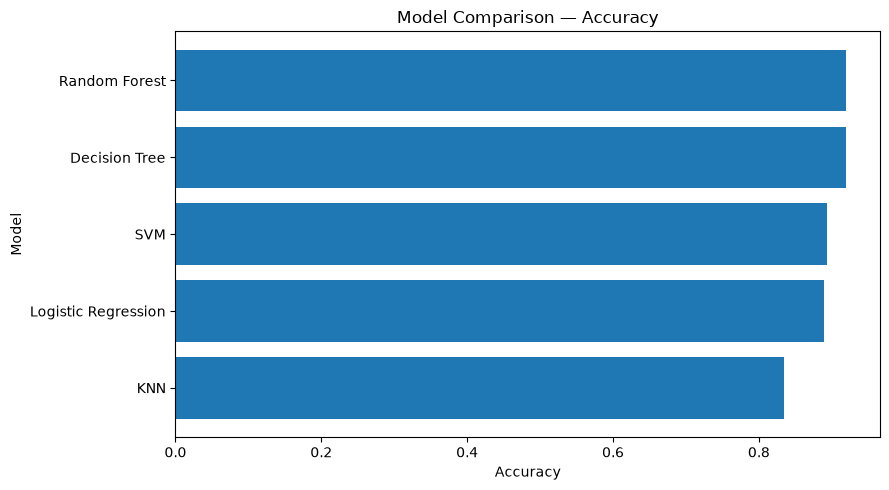

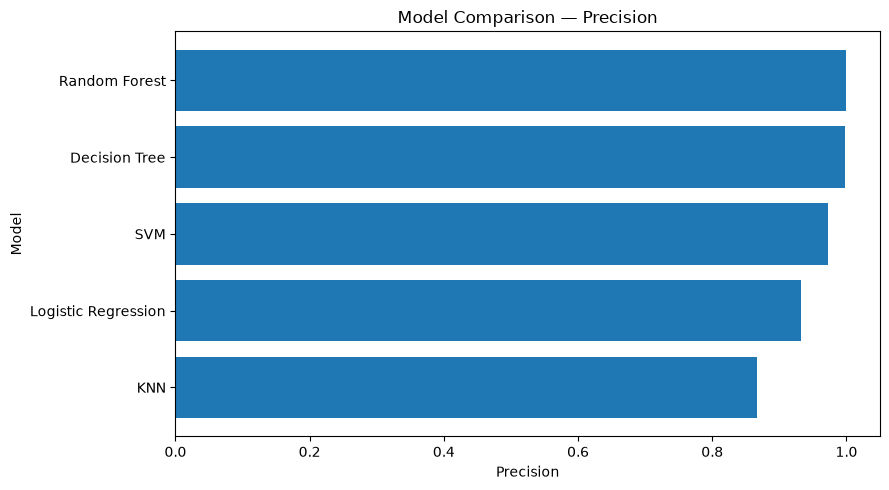

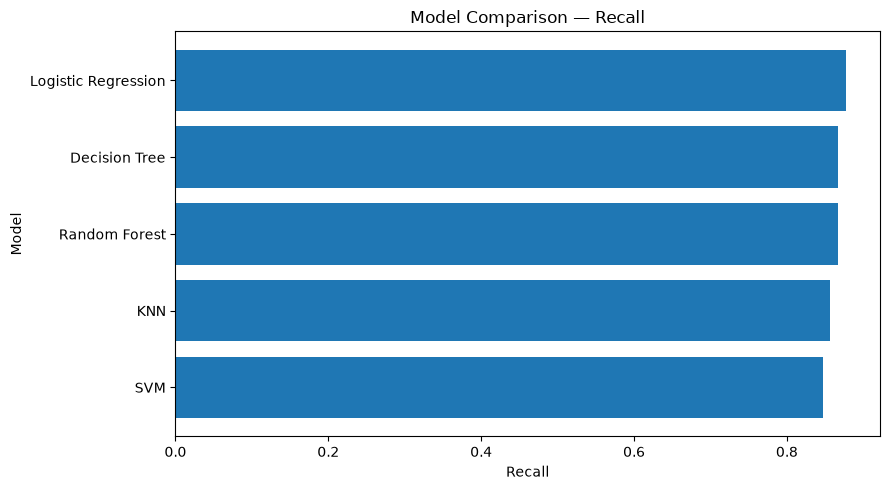

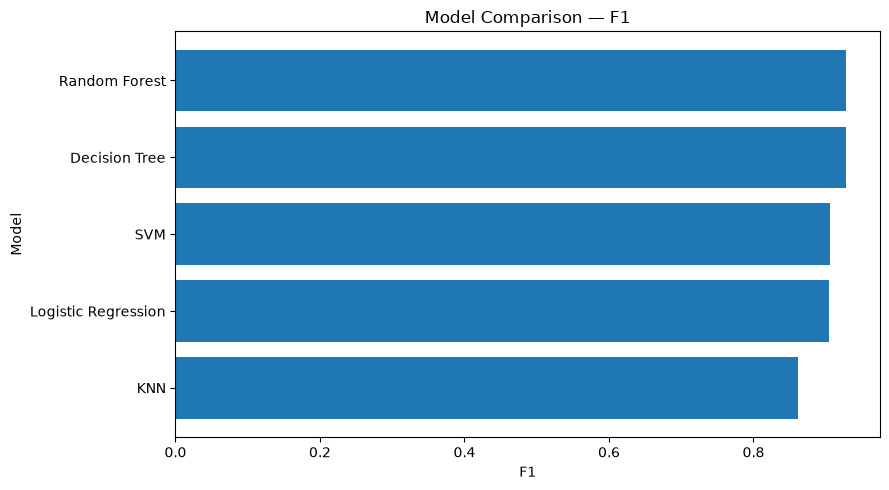

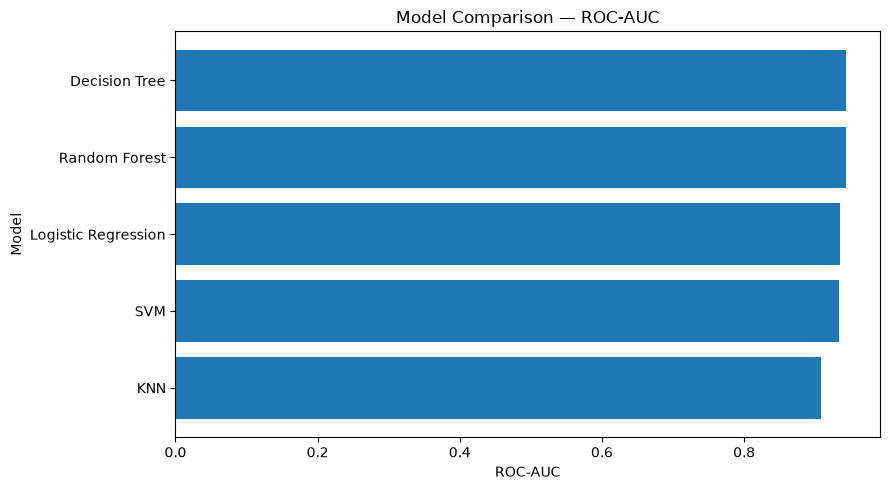

In [61]:
# ============================================================
# Visual comparison of the main metrics
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

for metric in metrics_to_plot:

    plot_df = (
        comparison_df
        .sort_values(
            metric,
            ascending=True
        )
    )

    plt.figure(figsize=(9, 5))

    plt.barh(
        plot_df["Model"],
        plot_df[metric]
    )

    plt.xlabel(metric)
    plt.ylabel("Model")

    plt.title(
        f"Model Comparison — {metric}"
    )

    plt.tight_layout()
    plt.show()

### Comparison interpretation

**Observation:**  
The table and charts show how the five classifiers perform across several complementary metrics.

**Interpretation:**  
A model may perform well on one metric while performing less favorably on another. For example, a classifier may obtain strong recall but lower precision.

**ML implication:**  
The final model should therefore be selected based on an overall trade-off rather than a single score.

The validation results above provide the evidence used in the subsequent hyperparameter experiments and model-selection stage.

## Hyperparameter Experiment 1 — Logistic Regression

### Research Question

> How does the regularization strength $C$ affect the performance of Logistic Regression?

In Logistic Regression, $C$ controls the **inverse strength of regularization**.

Therefore:

- **Smaller $C$** $\rightarrow$ stronger regularization $\rightarrow$ simpler model
- **Larger $C$** $\rightarrow$ weaker regularization $\rightarrow$ greater model flexibility

The relationship can be summarized as:

$$
C \uparrow
\Rightarrow
\text{Regularization Strength} \downarrow
$$

and:

$$
C \downarrow
\Rightarrow
\text{Regularization Strength} \uparrow
$$

### Hyperparameter Values

The following values of $C$ are evaluated:

$$
C \in \{0.01,\;0.1,\;1,\;10\}
$$

These values represent different levels of regularization, ranging from **strong regularization** to **weaker regularization**.

### Experimental Procedure

For each value of $C$:

1. The Logistic Regression model is trained using the training set.
2. The trained model is evaluated on the validation set.
3. The validation performance is recorded.
4. The results are compared across all tested values of $C$.

The validation set is used for **hyperparameter comparison**, while the test set remains untouched.

### Expected Interpretation

The experiment investigates whether stronger or weaker regularization produces better validation performance.

A very small $C$ may cause **underfitting** because the model is heavily constrained.

A very large $C$ may reduce the regularization effect and allow the model to fit the training data more closely, which can potentially increase the risk of **overfitting**.

> **Important:** The value of $C$ is selected based on validation performance. The test set is not used for choosing the best hyperparameter.

In [62]:
# ============================================================
# Logistic Regression regularization experiment
# ============================================================

logistic_experiment = []

for C in [0.01, 0.1, 1, 10]:

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    predictions, scores, metrics = (
        evaluate_classifier(
            model,
            X_val_processed,
            y_val
        )
    )

    logistic_experiment.append({
        "C": C,
        **metrics,
        "Training Time (s)": round(
            training_time,
            4
        )
    })

logistic_experiment_df = (
    pd.DataFrame(logistic_experiment)
    .sort_values(
        "F1",
        ascending=False
    )
)

display(
    logistic_experiment_df
)

,C,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
2,1.00,0.888867,0.932932,0.877889,0.904574,0.934740,0.1817
3,10.00,0.888800,0.932822,0.877889,0.904522,0.934744,0.2079
1,0.10,0.888600,0.932696,0.877667,0.904345,0.934716,0.1745
0,0.01,0.887600,0.931963,0.876667,0.903470,0.934281,0.2499


## Hyperparameter Experiment 2 — Random Forest

### Research Question

> Does increasing the number of trees improve predictive performance enough to justify the additional computational cost?

The parameter $n_{\text{estimators}}$ determines the number of trees in the Random Forest ensemble.

The experiment compares:

$$
n_{\text{estimators}} \in \{50,\;100,\;200,\;300\}
$$

For each configuration, **validation performance** and **training time** are recorded.

The results are compared to determine whether adding more trees provides a meaningful performance improvement relative to the additional computational cost.

In [63]:
# ============================================================
# Random Forest size experiment
# ============================================================

rf_experiment = []

for n_trees in [50, 100, 200, 300]:

    model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    predictions, scores, metrics = (
        evaluate_classifier(
            model,
            X_val_processed,
            y_val
        )
    )

    rf_experiment.append({
        "n_estimators": n_trees,
        **metrics,
        "Training Time (s)": round(
            training_time,
            4
        )
    })

rf_experiment_df = (
    pd.DataFrame(rf_experiment)
    .sort_values(
        "F1",
        ascending=False
    )
)

display(
    rf_experiment_df
)

,n_estimators,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,50,0.920067,1.0,0.866778,0.928635,0.942401,0.9076
1,100,0.920067,1.0,0.866778,0.928635,0.942701,2.6008
2,200,0.920067,1.0,0.866778,0.928635,0.942932,5.6208
3,300,0.920067,1.0,0.866778,0.928635,0.943119,7.9661


## Hyperparameter Experiment 3 — Decision Tree

### Research Question

> How does tree depth affect the balance between model complexity and predictive performance?

The parameter `max_depth` controls the maximum depth of the decision tree.

- A **shallow tree** may underfit because the model is too simple.
- A **deep tree** may overfit by fitting the training data too closely.

The experiment compares:

$$
max\_depth \in \{3,\;5,\;8,\;12,\;16\}
$$

The configurations are evaluated using the **validation set**.

In [64]:
# ============================================================
# Decision Tree depth experiment
# ============================================================

tree_experiment = []

for depth in [3, 5, 8, 12, 16]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    predictions, scores, metrics = (
        evaluate_classifier(
            model,
            X_val_processed,
            y_val
        )
    )

    tree_experiment.append({
        "max_depth": depth,
        **metrics,
        "Training Time (s)": round(
            training_time,
            4
        )
    })

tree_experiment_df = (
    pd.DataFrame(tree_experiment)
    .sort_values(
        "F1",
        ascending=False
    )
)

display(
    tree_experiment_df
)

,max_depth,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,3,0.920067,1.000000,0.866778,0.928635,0.938618,0.2680
1,5,0.920067,1.000000,0.866778,0.928635,0.943473,0.3072
2,8,0.919533,0.998337,0.867333,0.928236,0.944031,0.4135
3,12,0.918267,0.995285,0.867889,0.927232,0.941733,0.4887
4,16,0.916467,0.990379,0.869222,0.925854,0.939768,0.6218


# 18. Evaluation

## Research Question

> How accurately does the selected classifier distinguish diabetes-positive and diabetes-negative patients on unseen observations?

The model is evaluated using the following metrics.

### Accuracy

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Measures the proportion of all predictions that are correct.

### Precision

$$
Precision =
\frac{TP}
{TP+FP}
$$

Measures how many predicted positive cases are actually positive.

### Recall

$$
Recall =
\frac{TP}
{TP+FN}
$$

Measures how many actual positive cases are correctly identified.

### F1-score

$$
F1 =
2\frac{Precision\times Recall}
{Precision+Recall}
$$

Provides a balance between Precision and Recall.

### ROC-AUC

ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

### Confusion Matrix

$$
\begin{bmatrix}
TN & FP\\
FN & TP
\end{bmatrix}
$$

where:

- **TN** = True Negative
- **FP** = False Positive
- **FN** = False Negative
- **TP** = True Positive

<Figure size 900x700 with 0 Axes>

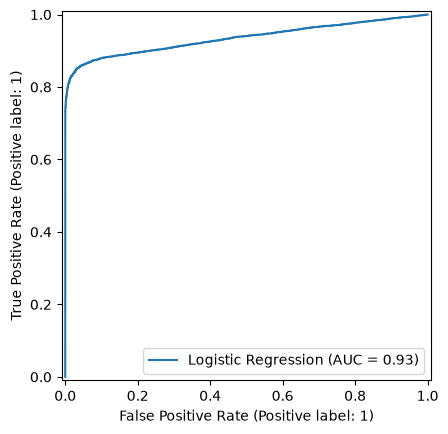

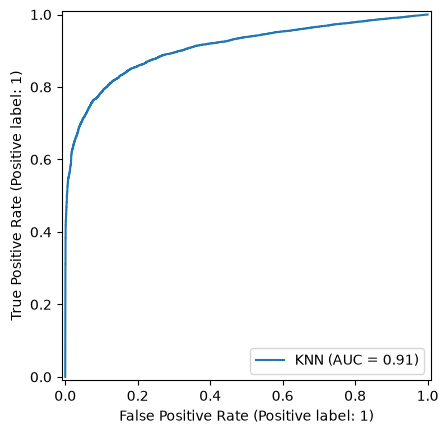

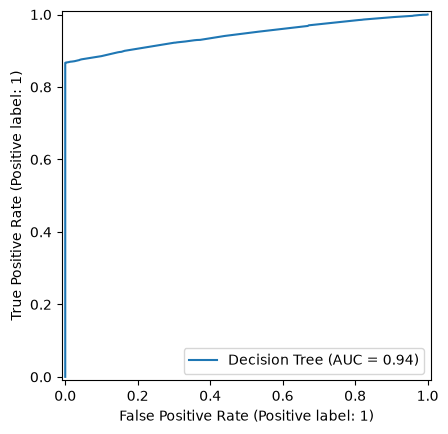

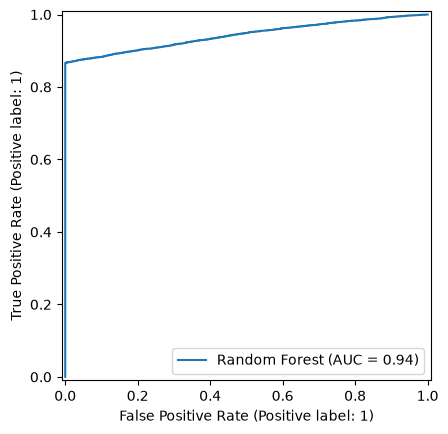

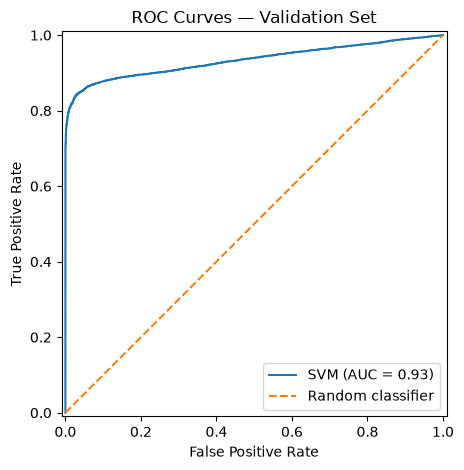

In [65]:
# ============================================================
# ROC curve comparison
# ============================================================

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(9, 7))

for model_name, scores in validation_scores.items():

    RocCurveDisplay.from_predictions(
        y_val,
        scores,
        name=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title(
    "ROC Curves — Validation Set"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()
plt.show()

### Metric interpretation

For a diabetes prediction system, Recall deserves particular attention because False Negatives correspond to positive cases that were not identified by the model.

However, Recall should not be maximized in isolation. A classifier that predicts too many positive cases may produce excessive False Positives and therefore low Precision.

F1-score provides a useful compromise between these two objectives.

ROC-AUC provides an additional perspective on the model's class-separation ability.

The final interpretation therefore considers the complete metric profile rather than a single number.

# 19. Error Analysis

## Research Question

> What types of patient observations are misclassified by the selected model?

Overall metrics summarize model performance but do not show the specific types of errors.

### False Positive (FP)

$$
Actual = 0,\quad Prediction = 1
$$

The model predicts diabetes for a patient who belongs to the negative class.

### False Negative (FN)

$$
Actual = 1,\quad Prediction = 0
$$

The model fails to identify a patient who belongs to the positive class.

For this application, **False Negatives deserve particular attention** because they represent positive cases that the model fails to detect.

In [66]:
# ============================================================
# Identify the current validation candidate
# ============================================================

current_best_model_name = (
    comparison_df
    .iloc[0]["Model"]
)

current_best_model = (
    trained_models[
        current_best_model_name
    ]
)

current_best_predictions = (
    validation_predictions[
        current_best_model_name
    ]
)

print(
    "Current validation candidate:",
    current_best_model_name
)

Current validation candidate: Random Forest


In [67]:
# ============================================================
# Create an error-analysis table
# ============================================================

error_df = X_val.copy()

error_df["actual"] = (
    y_val.values
)

error_df["predicted"] = (
    current_best_predictions
)

error_df["error_type"] = np.select(
    [
        (
            (error_df["actual"] == 0) &
            (error_df["predicted"] == 1)
        ),
        (
            (error_df["actual"] == 1) &
            (error_df["predicted"] == 0)
        )
    ],
    [
        "False Positive",
        "False Negative"
    ],
    default="Correct"
)

display(
    error_df["error_type"]
    .value_counts()
)

error_type
Correct           13801
False Negative     1199
Name: count, dtype: int64

In [68]:
# ============================================================
# Compare profiles of false positives and negatives
# ============================================================

error_features = [
    feature
    for feature in [
        "age",
        "bmi",
        "glucose_fasting",
        "glucose_postprandial",
        "hba1c",
        "systolic_bp",
        "diastolic_bp"
    ]
    if feature in error_df.columns
]

for error_type in [
    "False Positive",
    "False Negative"
]:

    subset = error_df[
        error_df["error_type"] == error_type
    ]

    print(
        f"\n{error_type}: {len(subset):,} cases"
    )

    if subset.empty:
        continue

    display(
        subset[
            error_features
        ].describe().T
    )


False Positive: 0 cases

False Negative: 1,199 cases


,count,mean,std,min,25%,50%,75%,max
age,1199.0,50.074229,15.089505,18.0,39.00,50.00,60.00,90.00
bmi,1199.0,25.699917,3.510641,15.0,23.40,25.70,28.00,37.70
glucose_fasting,1199.0,103.744787,10.273306,64.0,96.00,104.00,111.00,125.00
glucose_postprandial,1199.0,136.799833,20.363884,70.0,124.00,140.00,151.00,182.00
hba1c,1199.0,5.874646,0.474354,4.0,5.61,5.98,6.24,6.49
systolic_bp,1199.0,116.019183,14.294907,90.0,106.00,116.00,126.00,164.00
diastolic_bp,1199.0,74.576314,8.337455,50.0,69.00,74.00,80.00,103.00


# 20. Model Selection

## Research Question

> Which classifier should be selected for deployment after considering predictive performance, interpretability, computational cost, robustness, and deployment requirements?

The final decision is based on several dimensions.

### Predictive performance

Primary attention is given to:

- F1-score;
- Recall;
- ROC-AUC;
- Precision;
- Accuracy.

### Interpretability

Models such as Logistic Regression and Decision Tree are generally easier to explain than more complex nonlinear models.

### Computational cost

Training and inference time affect the practicality of deployment.

### Robustness

A model should perform consistently on unseen data rather than relying excessively on the training observations.

### Deployment

The selected model must be possible to save and reuse through a prediction service.

The best deployment candidate is therefore the model with the strongest overall trade-off rather than necessarily the highest score on one isolated metric.

In [69]:
# ============================================================
# Create a model-selection ranking
# ============================================================

selection_df = comparison_df.copy()

# Lower rank number means better validation performance.
selection_df["F1_rank"] = (
    selection_df["F1"]
    .rank(
        ascending=False,
        method="min"
    )
)

selection_df["Recall_rank"] = (
    selection_df["Recall"]
    .rank(
        ascending=False,
        method="min"
    )
)

selection_df["ROC_AUC_rank"] = (
    selection_df["ROC-AUC"]
    .rank(
        ascending=False,
        method="min"
    )
)

selection_df["Combined_rank"] = (
    selection_df[
        [
            "F1_rank",
            "Recall_rank",
            "ROC_AUC_rank"
        ]
    ]
    .sum(axis=1)
)

selection_df = (
    selection_df
    .sort_values(
        "Combined_rank"
    )
    .reset_index(drop=True)
)

display(
    selection_df
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s),F1_rank,Recall_rank,ROC_AUC_rank,Combined_rank
0,Decision Tree,0.919533,0.998337,0.867333,0.928236,0.944031,0.4287,2.0,2.0,1.0,5.0
1,Random Forest,0.920067,1.000000,0.866778,0.928635,0.942932,3.1413,1.0,3.0,2.0,6.0
2,Logistic Regression,0.888867,0.932932,0.877889,0.904574,0.934740,0.2092,4.0,1.0,3.0,8.0
3,SVM,0.893800,0.972445,0.847000,0.905398,0.933993,1571.5295,3.0,5.0,4.0,12.0
4,KNN,0.835067,0.867372,0.856000,0.861649,0.908827,0.0059,5.0,4.0,5.0,14.0


In [70]:
# ============================================================
# Select the leading validation candidate
# ============================================================

selected_model_name = (
    selection_df
    .iloc[0]["Model"]
)

selected_model = (
    trained_models[
        selected_model_name
    ]
)

print(
    "Selected validation candidate:",
    selected_model_name
)

Selected validation candidate: Decision Tree


### Selection rationale

The candidate above provides the strongest overall validation profile under the selected criteria.

The final decision must still be checked against:

- computational cost;
- interpretability;
- robustness;
- deployment constraints.


In [73]:
# ============================================================
# Final test-set evaluation
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay
final_test_pred, final_test_scores, final_test_metrics = (
    evaluate_classifier(
        selected_model,
        X_test_processed,
        y_test
    )
)

final_test_results = pd.DataFrame([
    {
        "Model": selected_model_name,
        **final_test_metrics
    }
])

display(
    final_test_results
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.92,0.997068,0.869208,0.928758,0.942061


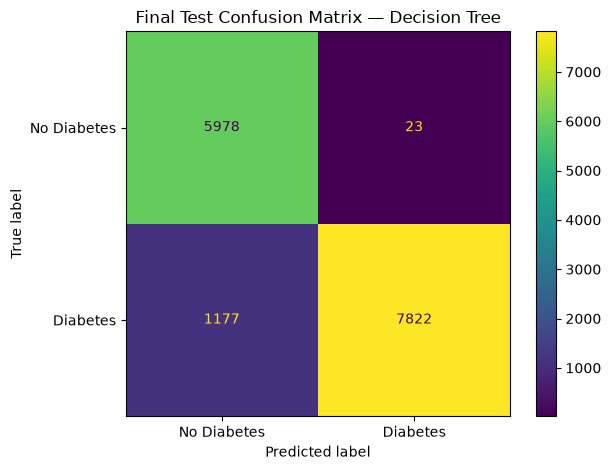

In [74]:
# ============================================================
# Final test confusion matrix
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title(
    f"Final Test Confusion Matrix — "
    f"{selected_model_name}"
)

plt.tight_layout()
plt.show()

# 21. Model Persistence

## Research Question

> Can the selected predictive system be stored and reused without retraining?

The complete pipeline is saved so that a raw patient record can be directly transformed into the numerical representation required by the trained classifier.

The deployment structure is:

$$
\text{Raw Input}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Trained Model}
\rightarrow
\text{Prediction}
$$

Saving the preprocessing and model together avoids manually reconstructing the preprocessing logic during deployment.

This ensures consistency in:

- imputation;
- categorical encoding;
- scaling;
- feature ordering;
- model inference.

> **Important:** The saved pipeline should use the same preprocessing steps and feature structure as those used during model training.

In [75]:
# ============================================================
# Build the complete final pipeline
# ============================================================

import joblib

# Recreate the selected model so that the final object
# contains a clean, reproducible estimator.
final_model_estimator = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),

    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )
}[selected_model_name]

final_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        final_model_estimator
    )
])

# Fit the complete pipeline on the training set only.
final_pipeline.fit(
    X_train,
    y_train
)

print(
    "Final pipeline trained successfully."
)

Final pipeline trained successfully.


In [76]:
# ============================================================
# Save the complete model pipeline
# ============================================================

MODEL_DIR = "model"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "diabetes_model_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print(
    "Saved pipeline:",
    MODEL_PATH
)

Saved pipeline: model\diabetes_model_pipeline.joblib


In [77]:
# ============================================================
# Save reproducibility metadata
# ============================================================

metadata = {
    "dataset_name": (
        "Diabetes Health Indicators Dataset"
    ),
    "dataset_url": (
        "https://www.kaggle.com/datasets/"
        "mohankrishnathalla/"
        "diabetes-health-indicators-dataset"
    ),
    "target": TARGET,
    "selected_model": selected_model_name,
    "random_seed": RANDOM_SEED,
    "python_version": platform.python_version(),
    "operating_system": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "original_feature_dimension": int(d_original),
    "final_feature_dimension": int(final_d)
}

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Saved metadata:",
    METADATA_PATH
)

Saved metadata: model\metadata.json


# 22. Inference Test

## Research Question

> Can the persisted pipeline process a previously unseen patient record and produce a prediction without retraining?

The inference process follows:

$$
\text{Raw Input}
\rightarrow
\text{Validation}
\rightarrow
\text{Saved Preprocessing}
\rightarrow
\text{Saved Model}
\rightarrow
\text{Prediction}
$$

During inference, **no new scaler, encoder, or imputer is fitted**.

The exact preprocessing pipeline learned during training is reused to ensure that unseen data is transformed consistently before prediction.

> **Important:** Inference only performs transformation and prediction. No model parameters or preprocessing parameters are learned from the new input.

In [78]:
# ============================================================
# Load the persisted pipeline
# ============================================================

loaded_pipeline = joblib.load(
    MODEL_PATH
)

print(
    "Persisted pipeline loaded successfully."
)

Persisted pipeline loaded successfully.


In [79]:
# ============================================================
# Run inference on one unseen patient
# ============================================================

# Select one observation from the held-out test set.
# The raw feature structure is preserved.
sample_patient = X_test.iloc[[0]].copy()

print("Input patient:")
display(
    sample_patient
)

# Predict the diabetes class
prediction = loaded_pipeline.predict(
    sample_patient
)

print(
    "\nPredicted diabetes class:",
    int(prediction[0])
)

# Predict probability where supported
if hasattr(
    loaded_pipeline,
    "predict_proba"
):

    probability = (
        loaded_pipeline
        .predict_proba(
            sample_patient
        )[0, 1]
    )

    print(
        f"Probability of diabetes: "
        f"{probability:.4f}"
    )

Input patient:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
46462,43,Male,Hispanic,Graduate,Middle,Unemployed,Never,2,58,6.2,...,72,88,180,55,85,119,108,173,16.81,6.71



Predicted diabetes class: 1
Probability of diabetes: 1.0000


# Diabetes Prediction — Final Summary

## Data Representation

The dataset starts as a Kaggle CSV file and is loaded into a Pandas DataFrame.

For one patient:

$$
x_i \in \mathbb{R}^{d}
$$

For the complete dataset:

$$
X \in \mathbb{R}^{N \times d}
$$

After preprocessing:

$$
X_{\text{model}}
\in
\mathbb{R}^{N \times d_{\text{final}}}
$$

Categorical variables are converted into numerical representations, while numerical variables are imputed and standardized.

## Modeling

Five classification algorithms were evaluated:

- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVM

Hyperparameter experiments were conducted to investigate the effects of regularization, ensemble size, and tree depth.

## Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

## Error Analysis

False Positives and False Negatives were analyzed separately to identify potential weaknesses of the selected classifier.

## Model Selection

The final model was selected based on a combination of:

- Validation performance
- Recall
- F1-score
- ROC-AUC
- Interpretability
- Computational cost
- Robustness
- Deployment considerations

## Persistence and Inference

The complete preprocessing and model pipeline was persisted using `joblib` and reloaded for an independent inference test.

The final system follows:

$$
\boxed{
\text{Data}
\rightarrow
\text{Understand}
\rightarrow
\text{Clean}
\rightarrow
\text{Represent}
\rightarrow
\text{Learn}
\rightarrow
\text{Evaluate}
\rightarrow
\text{Persist}
\rightarrow
\text{Deploy}
}
$$